In [1]:
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse
from scipy.signal import savgol_filter
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GroupKFold, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from tools import load_all


In [2]:
ppc = [200, 600, 1000, 1400, 1800]
vfl = [0.3, 0.4, 0.5, 0.6]

combinations = list(product(ppc, vfl))

In [3]:
PROJECT_DIR = Path.cwd()  # run the notebook from the repo root
CACHE_DIR = PROJECT_DIR / "cache"
FIG_DIR = PROJECT_DIR / "results" / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SIMS = {}
for p, v in combinations:
    sim_label = f"dx0.1_dt0.095_{p}ppc_{v}vfl"
    sim_path = PROJECT_DIR / "simulations" / sim_label / "weibel.in"
    SIMS[sim_label] = sim_path

sim_labels = list(SIMS.keys())

ELECTRON_SPECIES = ("electrons-up", "electrons-down")

# grid / time parameters (from the deck) - Hardcoded in case no simulation is available
NX = 128
DX = 0.1  # 12.8 / 128 [c/w_p]
DT_DUMP = 0.095  # dt * ndump
TMAX = 40
time_array = np.arange(0, TMAX + DT_DUMP, DT_DUMP)


SPECIES_KEYS = ["n", "vfl1", "vfl2", "vfl3", "ufl1", "P11", "P12", "T11", "Q111", "Q112", "nvfl1"]
FIELD_KEYS = ["b1", "b2", "b3", "e1", "e2", "e3"]


In [4]:
from download_data import download_zenodo_repo

# Call it using your specific ID
download_zenodo_repo(record_id="21431859", output_dir=CACHE_DIR)


Fetching metadata for Zenodo Record ID: 21431859...
Found 40 files. Starting download...
--------------------------------------------------
Skipping dx0.1_dt0.095_200ppc_0.5vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1800ppc_0.5vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1000ppc_0.4vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1800ppc_0.3vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_200ppc_0.3vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_600ppc_0.6vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1000ppc_0.4vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1000ppc_0.6vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_600ppc_0.3vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_600ppc_0.5vfl_field

True

## Helper / Utilities functions for the project

# 0) Understanding the data and the problem

In [5]:
data = load_all(
    "dx0.1_dt0.095_1800ppc_0.6vfl", ["electrons-up", "electrons-down"], simulations=SIMS, cache_dir=CACHE_DIR, fields=FIELD_KEYS
)

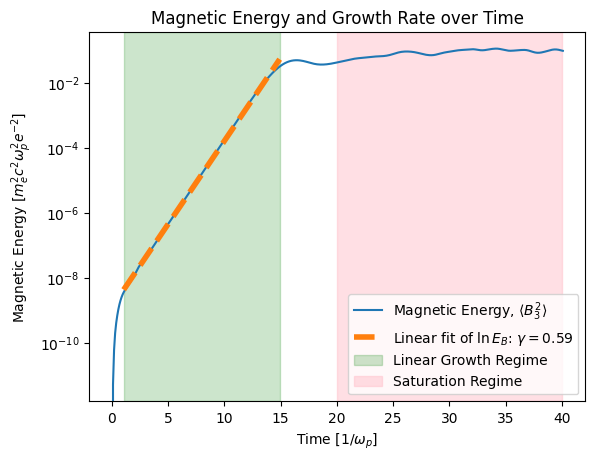

In [6]:
b3 = data["b3"]
magnetic_energy = (np.abs(b3) ** 2).mean(1)

# Fit the growth rate in log space: ln E_B = ln a + 2*gamma*t is linear in t, so an
# ordinary least-squares line weights all times in the window equally. (A nonlinear
# fit of a*exp(b*t) in linear space is dominated by the largest late-time values.)
time_cut = (time_array > 1) & (time_array < 15)
slope, intercept = np.polyfit(time_array[time_cut], np.log(magnetic_energy[time_cut]), 1)
gamma = slope / 2.0

plt.plot(
    time_array,
    magnetic_energy,
    label=r"Magnetic Energy, $\langle B_3^2\rangle$",
)
plt.plot(
    time_array[time_cut],
    np.exp(intercept + slope * time_array[time_cut]),
    label=rf"Linear fit of $\ln E_B$: $\gamma = {gamma:.2f}$",
    linestyle="--",
    lw=4,
)
# define regions of interest: linear growth regime and saturation regime
linear_growth_region = (time_array > 1) & (time_array < 15)
saturation_region = (time_array > 20) & (time_array < 40)
plt.axvspan(
    time_array[linear_growth_region][0], time_array[linear_growth_region][-1], color="green", alpha=0.2, label="Linear Growth Regime"
)
plt.axvspan(time_array[saturation_region][0], time_array[saturation_region][-1], color="pink", alpha=0.5, label="Saturation Regime")

plt.xlabel(r"Time $[1/\omega_p]$")
plt.ylabel(r"Magnetic Energy $[m_e^2 c^2 \omega_p^2 e^{-2}]$")
plt.title("Magnetic Energy and Growth Rate over Time")
plt.legend()
plt.yscale("log")

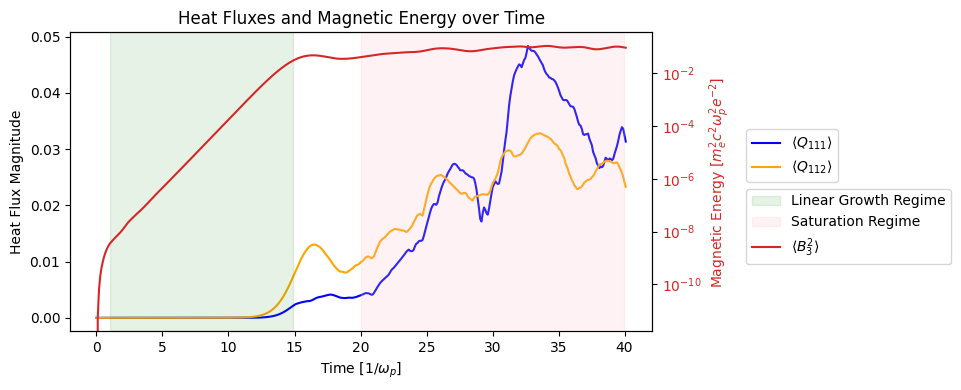

In [7]:
# When does the heat flux become relevant? Let's look at the heat fluxes and their evolution over time.
# We will focus on the centered third moments Q111 and Q112, which are related to the heat flux in the plasma.

Q111 = data["Q111"]
Q112 = data["Q112"]

# Let's plot the time evolution of the heat fluxes Q111 and Q112 to see when they become significant.
# left axis for the heat fluxes, right axis for the magnetic energy to compare

plt.figure(figsize=(10, 4))
left_axis = plt.gca()
right_axis = left_axis.twinx()
right_axis.axvspan(
    time_array[linear_growth_region][0], time_array[linear_growth_region][-1], color="green", alpha=0.1, label="Linear Growth Regime"
)
right_axis.axvspan(time_array[saturation_region][0], time_array[saturation_region][-1], color="pink", alpha=0.2, label="Saturation Regime")

# Plot the heat fluxes on the left axis
left_axis.plot(time_array, np.abs(Q111).mean(1), label=r"$\langle Q_{111} \rangle$", color="blue")
left_axis.plot(time_array, np.abs(Q112).mean(1), label=r"$\langle Q_{112} \rangle$", color="orange")
left_axis.set_ylabel("Heat Flux Magnitude", color="black")
left_axis.tick_params(axis="y", labelcolor="black")

# Plot the magnetic energy on the right axis
right_axis.plot(time_array, magnetic_energy, label=r"$\langle B_3^2 \rangle$", color="tab:red")
right_axis.set_ylabel(r"Magnetic Energy $[m_e^2 c^2 \omega_p^2 e^{-2}]$", color="tab:red")
right_axis.tick_params(axis="y", labelcolor="tab:red")
right_axis.set_yscale("log")


# add regions of interest: linear growth regime and saturation regime

# add legends for both axes
left_axis.legend(loc="upper left", bbox_to_anchor=(1.15, 0.7))
right_axis.legend(loc="upper left", bbox_to_anchor=(1.15, 0.5))
plt.title("Heat Fluxes and Magnetic Energy over Time")
left_axis.set_xlabel(r"Time $[1/\omega_p]$")
plt.tight_layout()
plt.show()

# Heat Flux is important in the saturation regime, where the magnetic energy has saturated and the plasma dynamics
# are dominated by nonlinear effects. The heat fluxes Q111 (and Q112) become significant in this regime,
# indicating that they play a crucial role in the energy transport and dissipation processes within the plasma.

# 1) Identify saturation regime in Weibel instability simulations using Gaussian Mixture Models (GMMs)

We will use Gaussian Mixture Models (GMMs) to identify different regimes in the simulation, particularly focusing on the saturation regime (where the heat-flux is more relevant).

In [8]:
GMM_DIR = FIG_DIR / "gmm"
GMM_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_LABELS = [
    r"$\log_{10}\langle B_3^2\rangle$",
    r"$\gamma(t)$",
    r"$\log_{10}\langle T_{11}\rangle$",
    r"$\log_{10}\langle Q_{111}^2\rangle$",
]
KS = range(1, 7)
ELBOW_FRAC = 0.07
SEED = 0

datasets = sim_labels

In [9]:
def snapshot_features(data_set) -> np.ndarray:
    """
    This method computes the features for each snapshot in time, which are used for clustering and analysis. The features include:

    - log10 of the mean squared magnetic field component B3: this allows us to track the growth of the magnetic field over time

    - growth rate of the magnetic field: computed as the Savitzky-Golay filter of the log of the mean squared B3,
    divided by 2.0 (assuming `$B \\propto exp(\\gamma*t)$`)

    - log10 of the mean temperature component T11: this allows us to track the evolution of the
    temperature over time (saturation results in heating)

    - log10 of the mean squared third moment component Q111: this allows us to track the evolution of the
    third moment over time (saturation results in heating)
    """
    data = load_all(data_set, ELECTRON_SPECIES, cache_dir=CACHE_DIR, fields=FIELD_KEYS, simulations=SIMS)

    # Magnectic field energy density (B3^2) averaged over x1, for each snapshot in time
    b3sq = (data["b3"].astype(np.float64) ** 2).mean(1)

    # Temperature tensor T11 averaged over x1, for each snapshot in time
    T11 = (data["T11"].astype(np.float64)).mean(1)
    # Third moment tensor Q111 squared, averaged over x1, for each snapshot in time
    q_sq = ((data["Q111"].astype(np.float64)) ** 2).mean(1)

    # Log(B3^2) = 2 * log(B3) = 2 * gamma * t, so the growth rate is given by the derivative of log(B3^2) with respect to time, divided by 2
    ln_b3 = np.log(b3sq + 1e-16)
    growth = savgol_filter(ln_b3, window_length=15, polyorder=2, deriv=1, delta=DT_DUMP) / 2.0
    return np.stack([np.log10(b3sq + 1e-16), growth, np.log10(T11 + 1e-12), np.log10(q_sq + 1e-18)], axis=1)

K=1: BIC=2856.8
K=2: BIC=-2282.2
K=3: BIC=-4016.5
K=4: BIC=-4910.2
K=5: BIC=-5593.7
K=6: BIC=-6300.8
elbow selects K=6 (BIC min would give K=6)


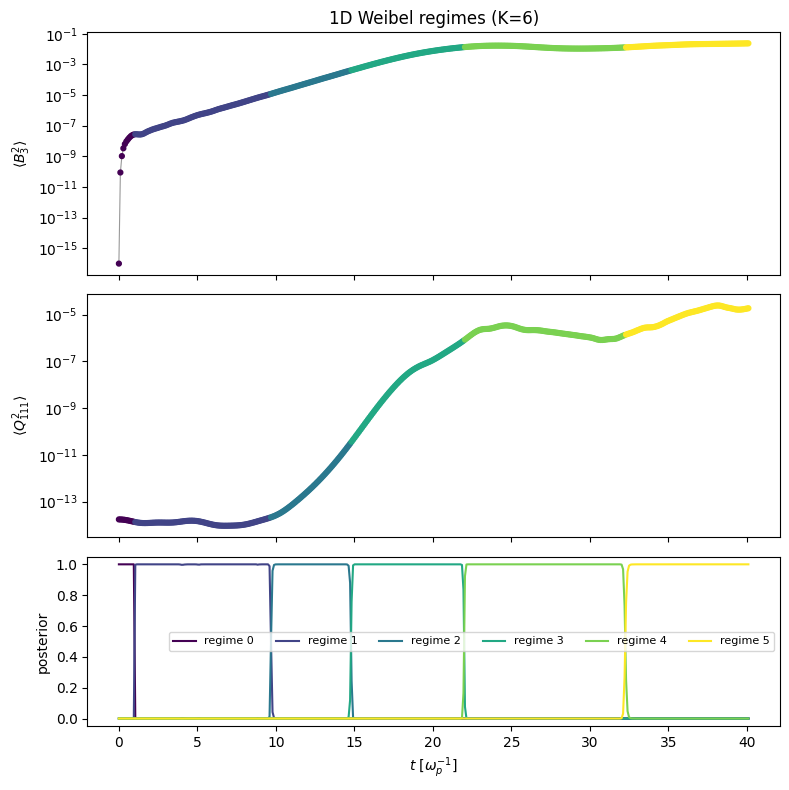

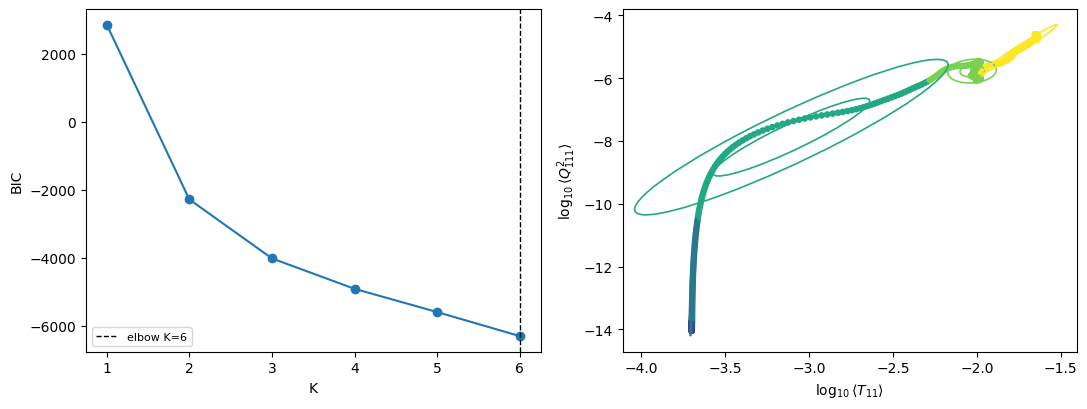

K=1: BIC=2644.8
K=2: BIC=-2159.0
K=3: BIC=-3994.9
K=4: BIC=-4598.4
K=5: BIC=-5353.1
K=6: BIC=-5762.2
elbow selects K=5 (BIC min would give K=6)


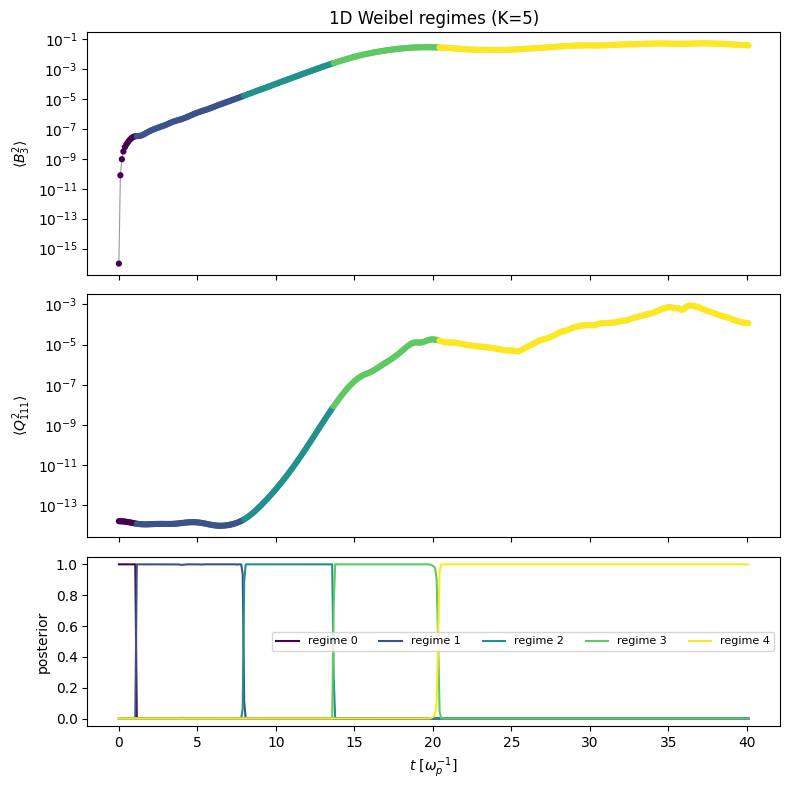

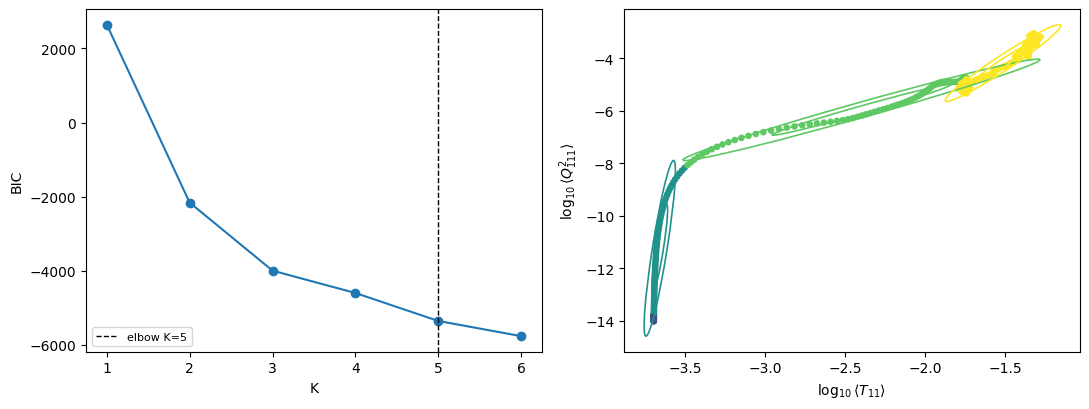

K=1: BIC=2511.1
K=2: BIC=-2198.6
K=3: BIC=-4144.7
K=4: BIC=-4626.6
K=5: BIC=-5233.1
K=6: BIC=-5578.2
elbow selects K=3 (BIC min would give K=6)


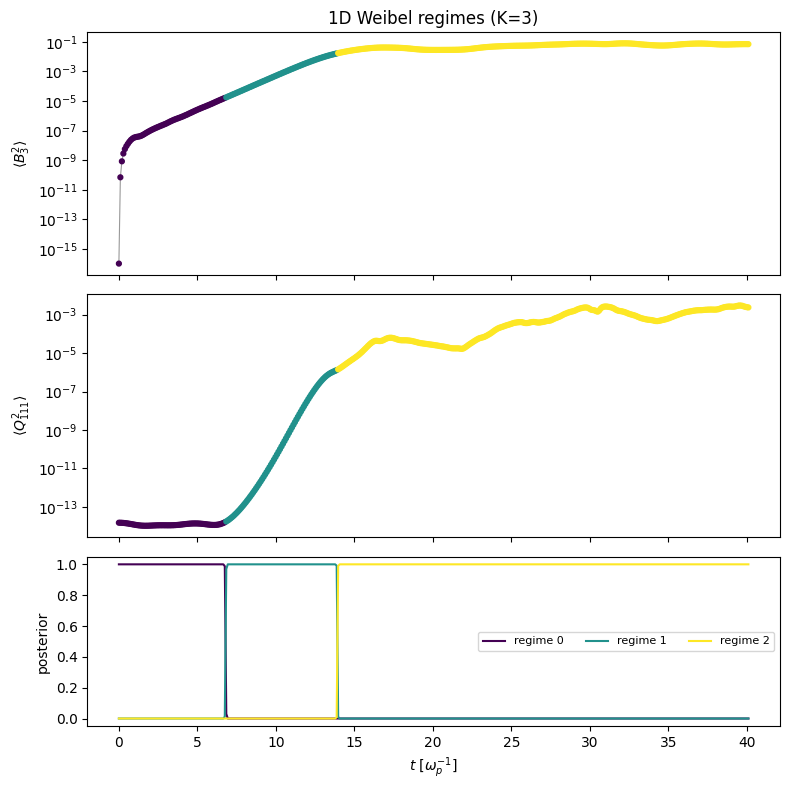

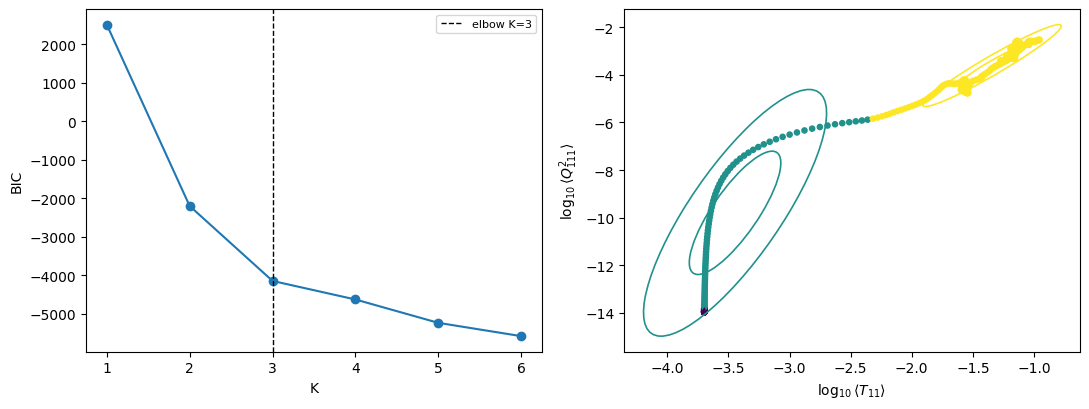

K=1: BIC=2440.3
K=2: BIC=-2087.3
K=3: BIC=-3607.7
K=4: BIC=-4066.1
K=5: BIC=-4712.3
K=6: BIC=-5204.3
elbow selects K=3 (BIC min would give K=6)


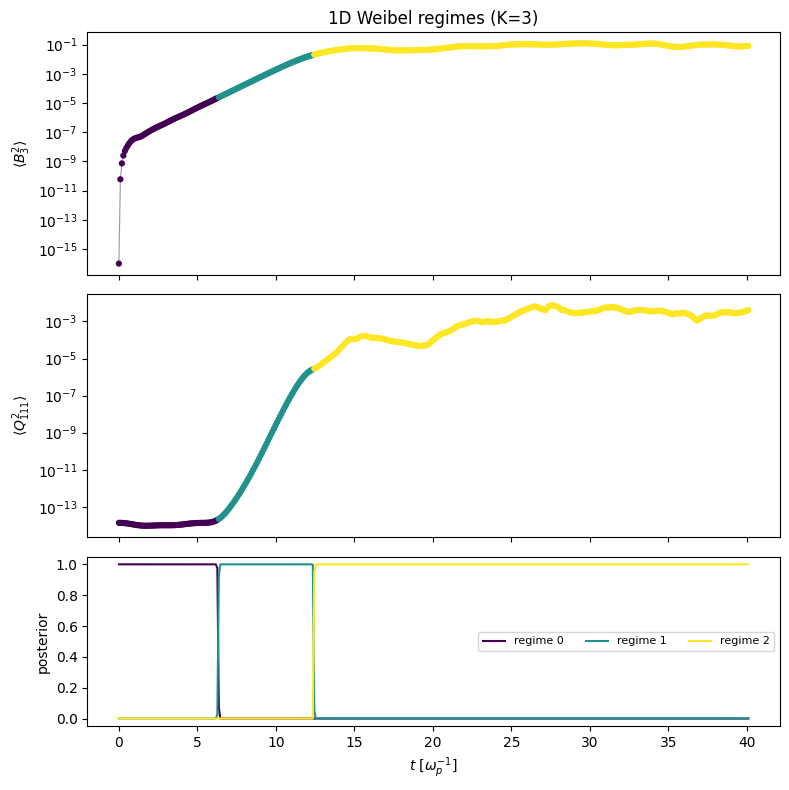

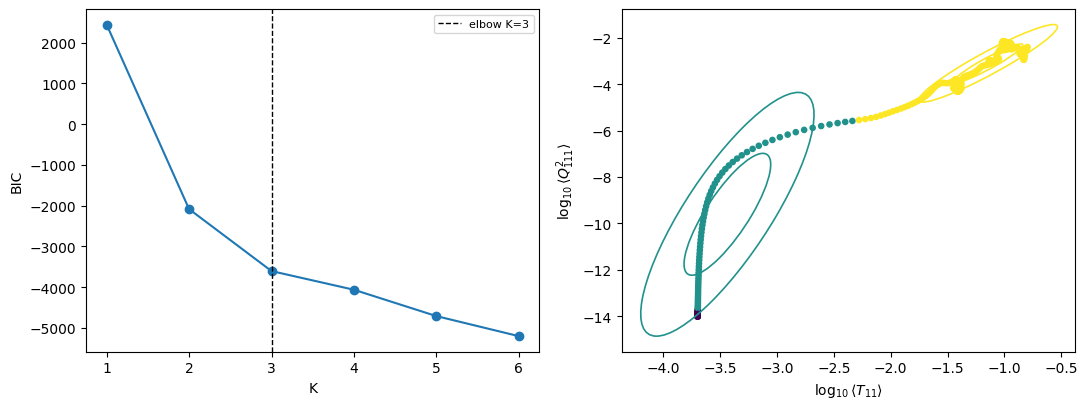

K=1: BIC=2945.4
K=2: BIC=-2358.3
K=3: BIC=-4292.8
K=4: BIC=-5299.4
K=5: BIC=-6200.1
K=6: BIC=-6803.5
elbow selects K=5 (BIC min would give K=6)


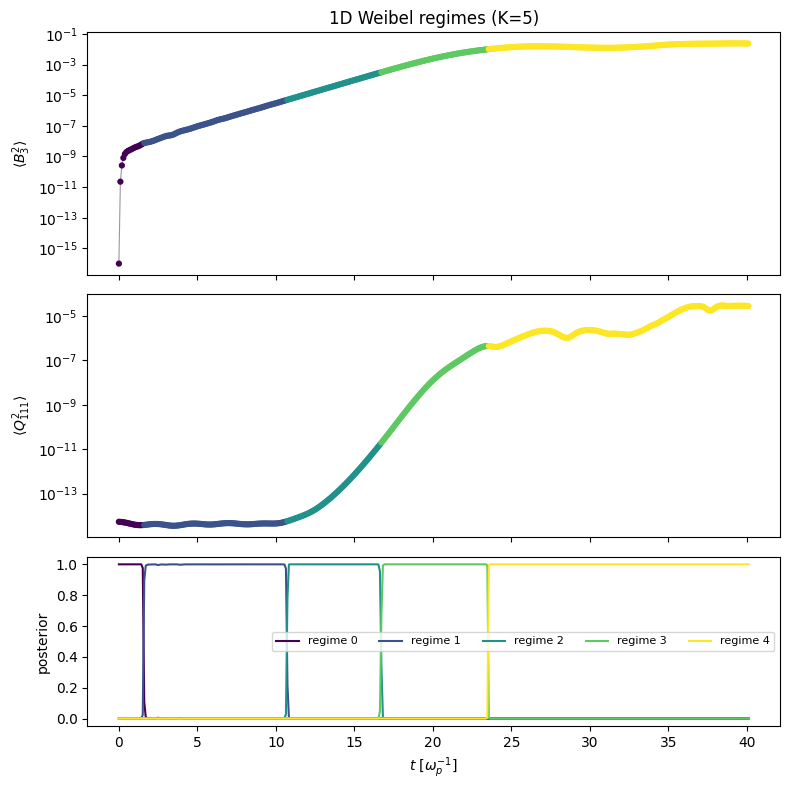

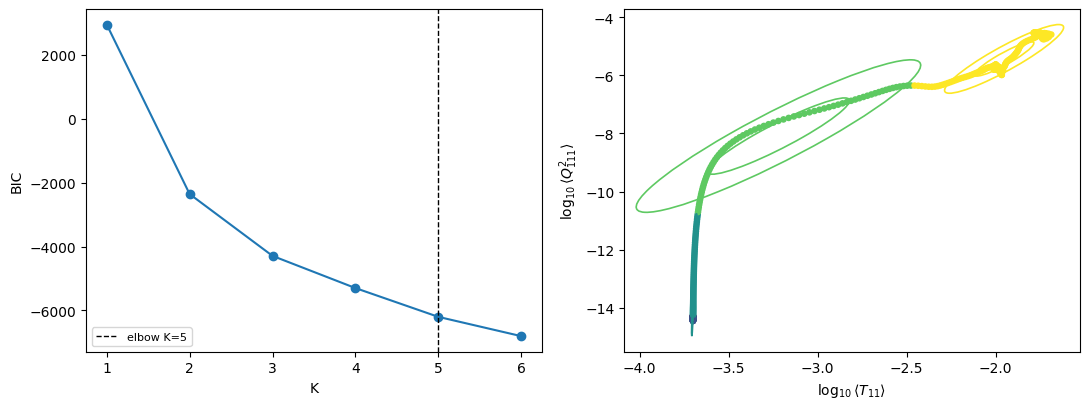

K=1: BIC=2728.8
K=2: BIC=-2281.5
K=3: BIC=-4090.3
K=4: BIC=-5044.9
K=5: BIC=-5695.2
K=6: BIC=-6186.1
elbow selects K=5 (BIC min would give K=6)


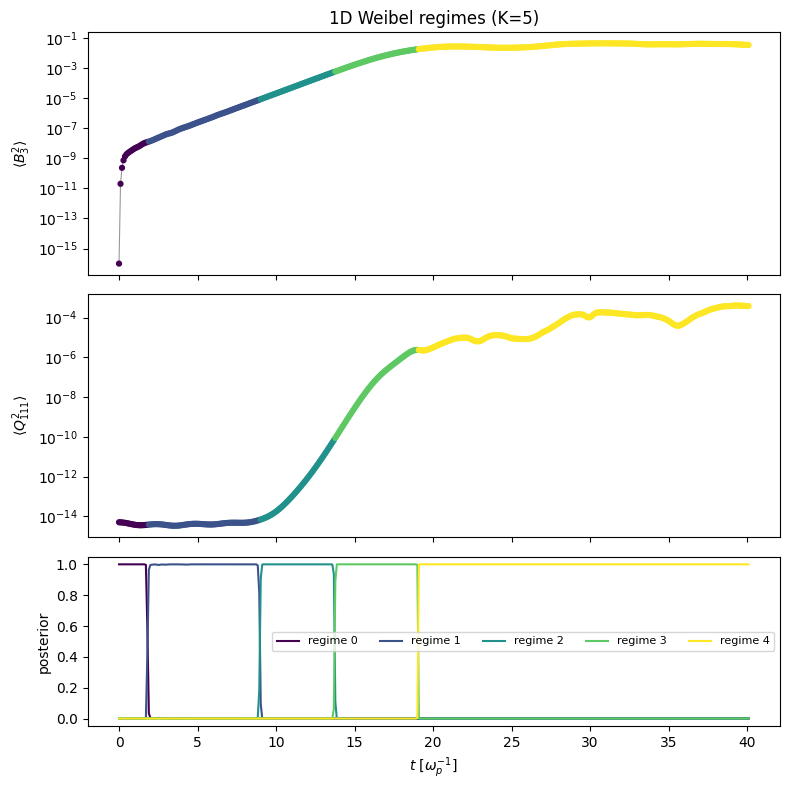

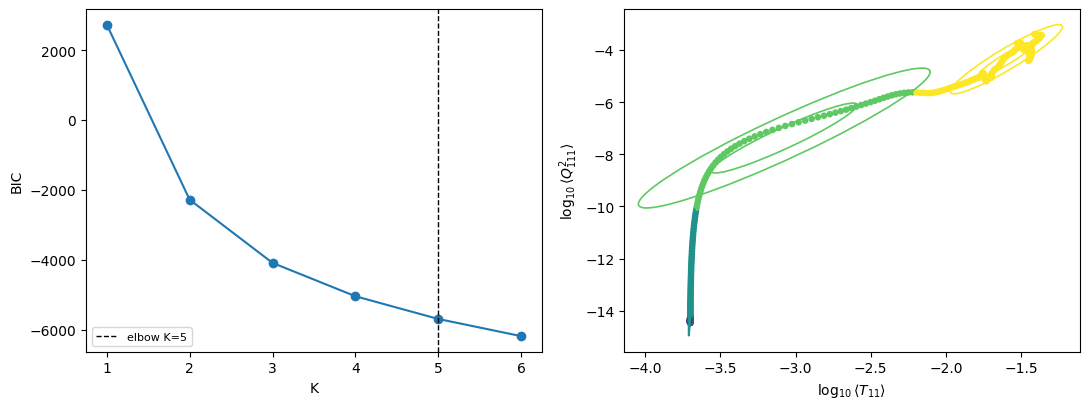

K=1: BIC=2586.6
K=2: BIC=-2141.4
K=3: BIC=-3739.3
K=4: BIC=-4830.8
K=5: BIC=-5262.3
K=6: BIC=-5586.6
elbow selects K=4 (BIC min would give K=6)


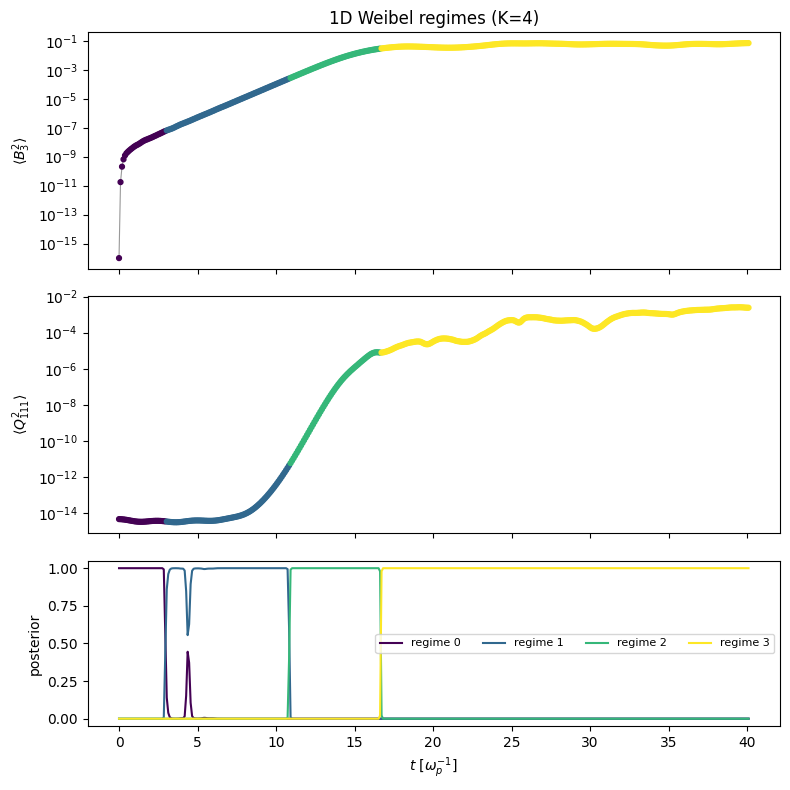

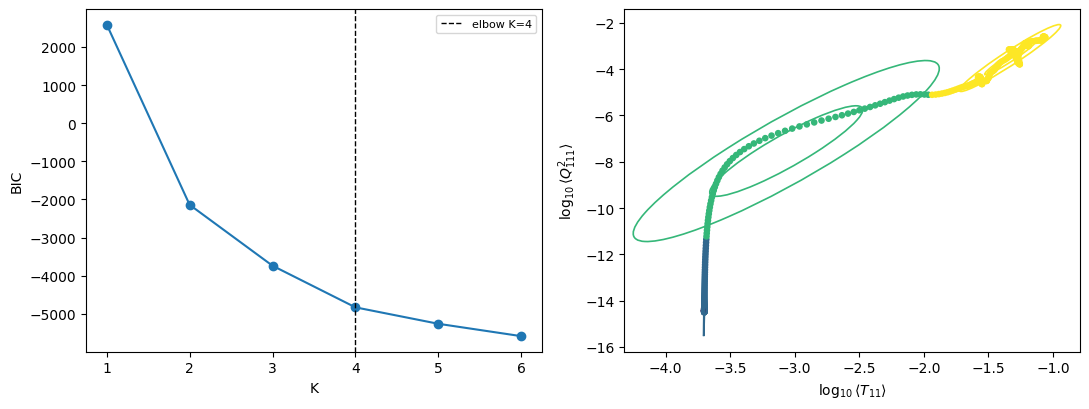

K=1: BIC=2489.5
K=2: BIC=-1930.7
K=3: BIC=-3408.7
K=4: BIC=-4541.0
K=5: BIC=-4906.5
K=6: BIC=-5230.9
elbow selects K=4 (BIC min would give K=6)


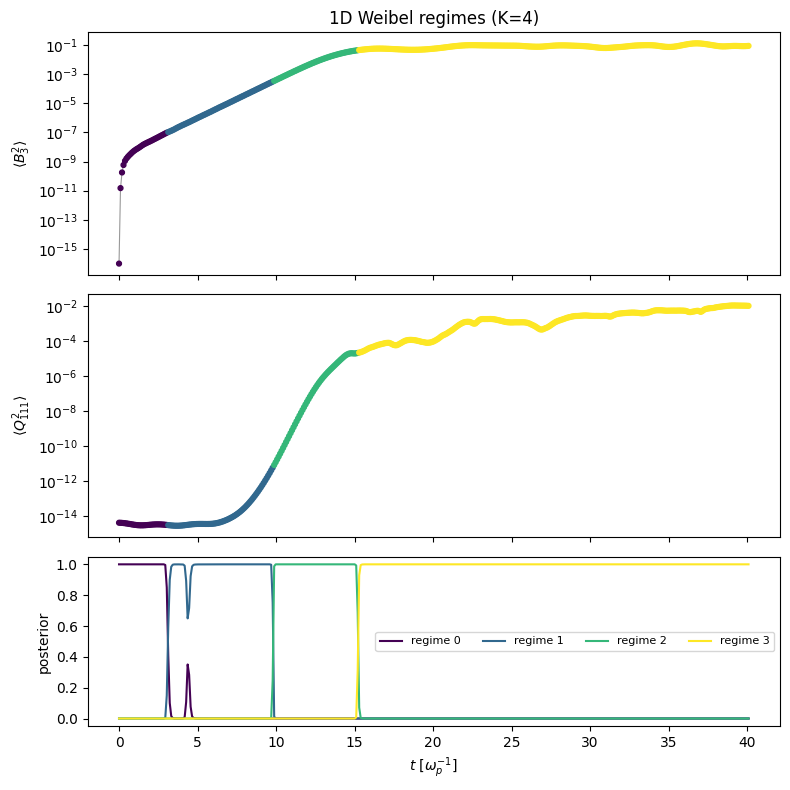

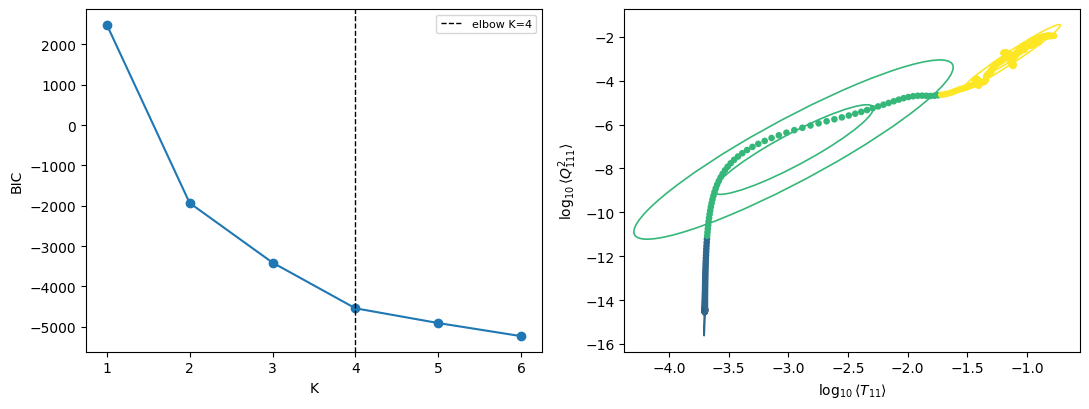

K=1: BIC=2918.5
K=2: BIC=-2708.2
K=3: BIC=-4426.2
K=4: BIC=-5217.7
K=5: BIC=-6219.5
K=6: BIC=-6757.2
elbow selects K=5 (BIC min would give K=6)


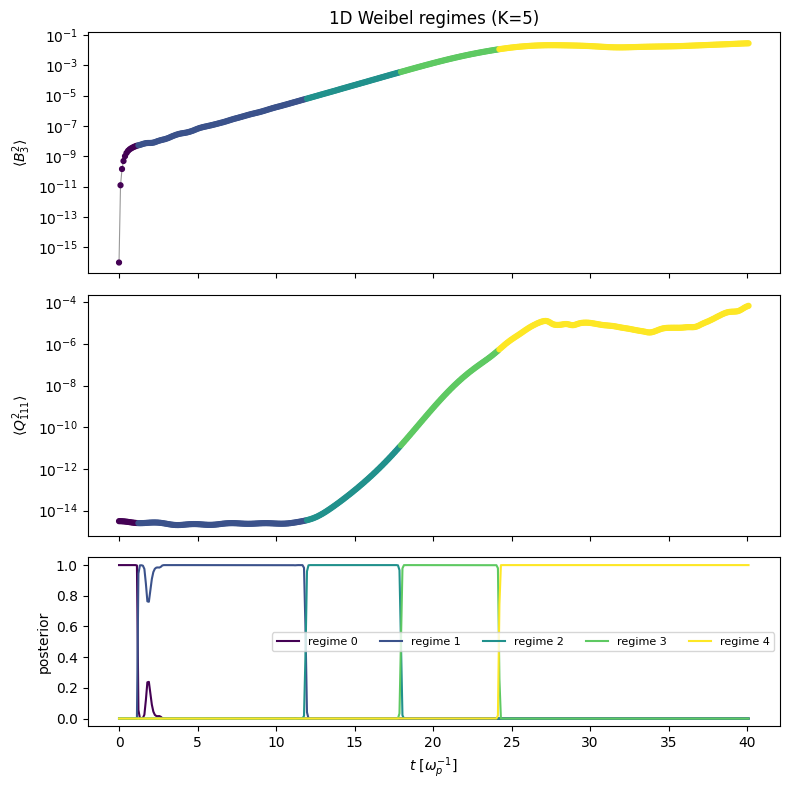

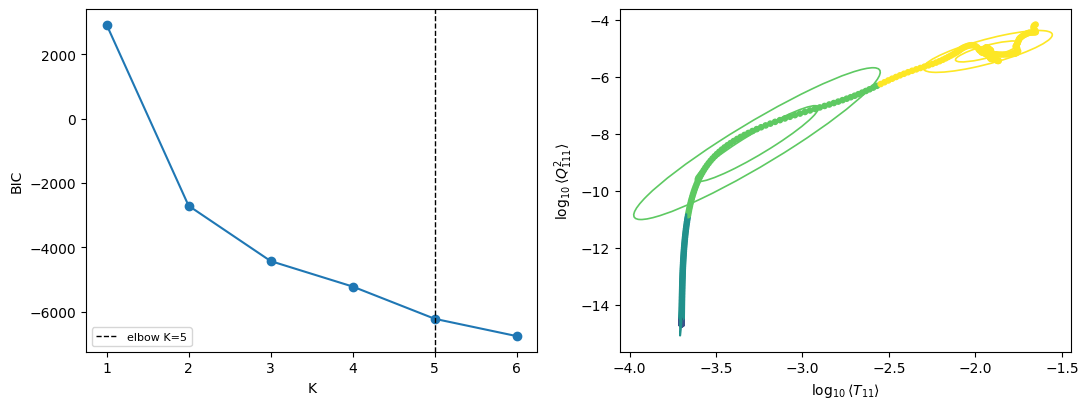

K=1: BIC=2674.5
K=2: BIC=-2372.5
K=3: BIC=-4137.5
K=4: BIC=-4938.8
K=5: BIC=-5581.1
K=6: BIC=-6006.0
elbow selects K=5 (BIC min would give K=6)


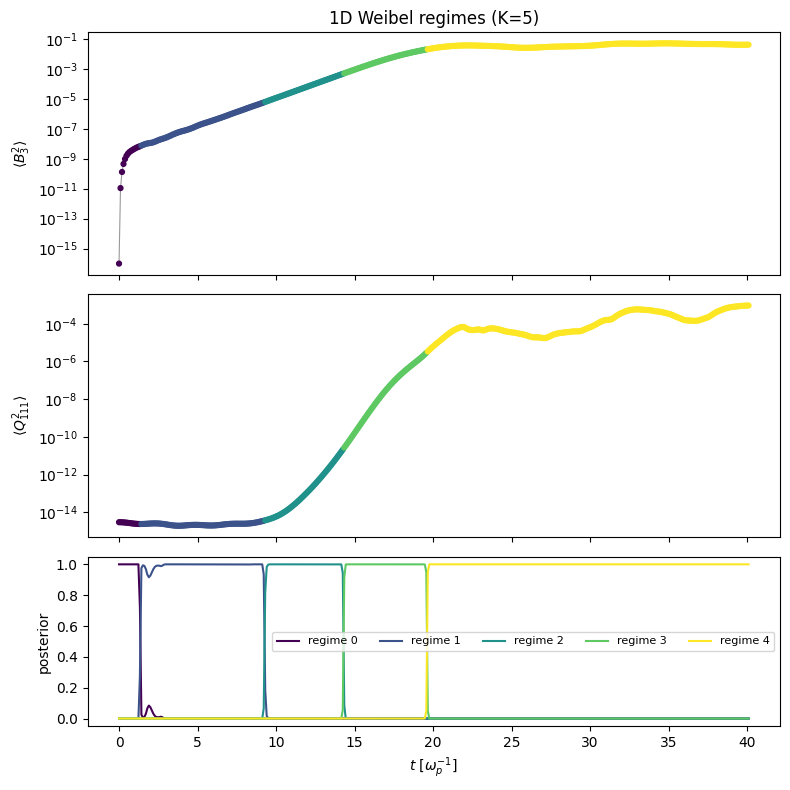

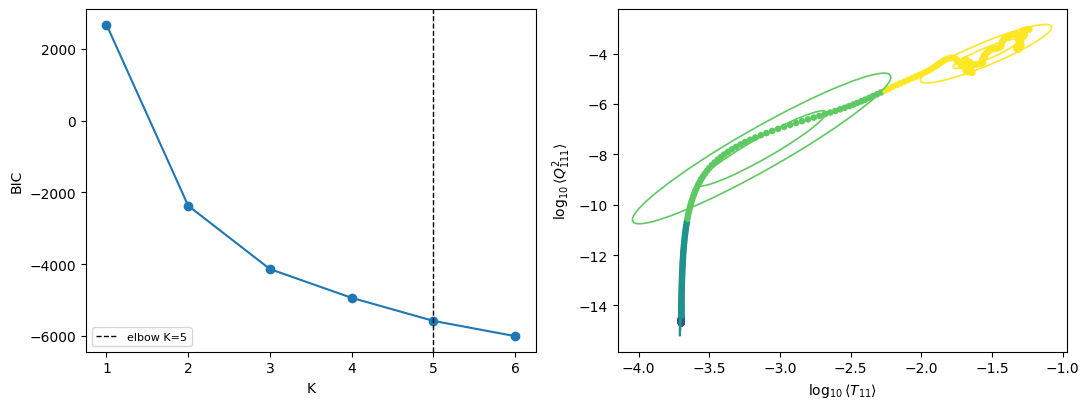

K=1: BIC=2529.2
K=2: BIC=-2351.3
K=3: BIC=-4097.2
K=4: BIC=-4813.2
K=5: BIC=-5386.8
K=6: BIC=-5799.2
elbow selects K=4 (BIC min would give K=6)


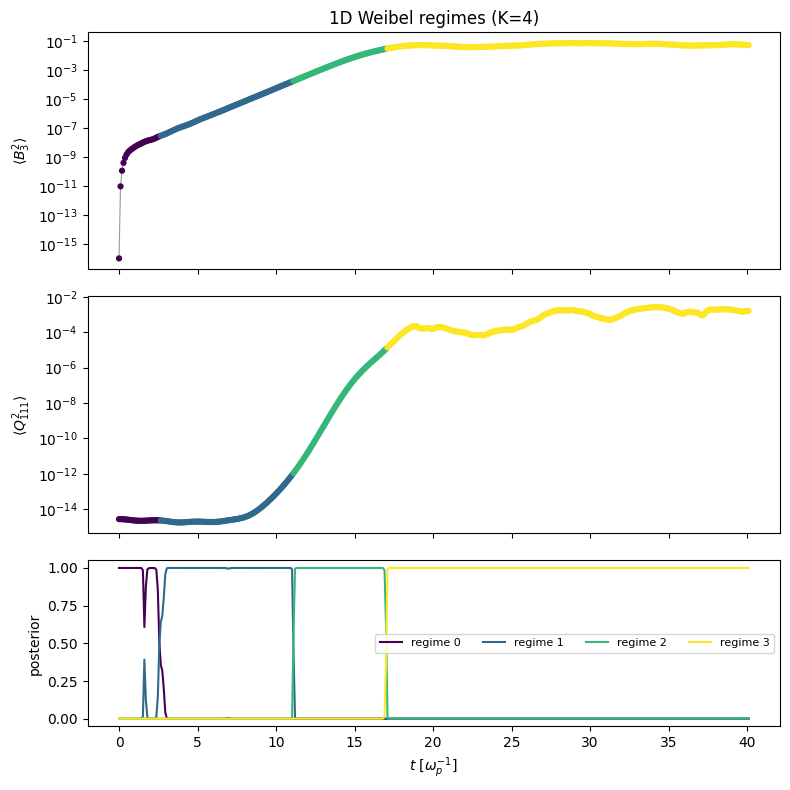

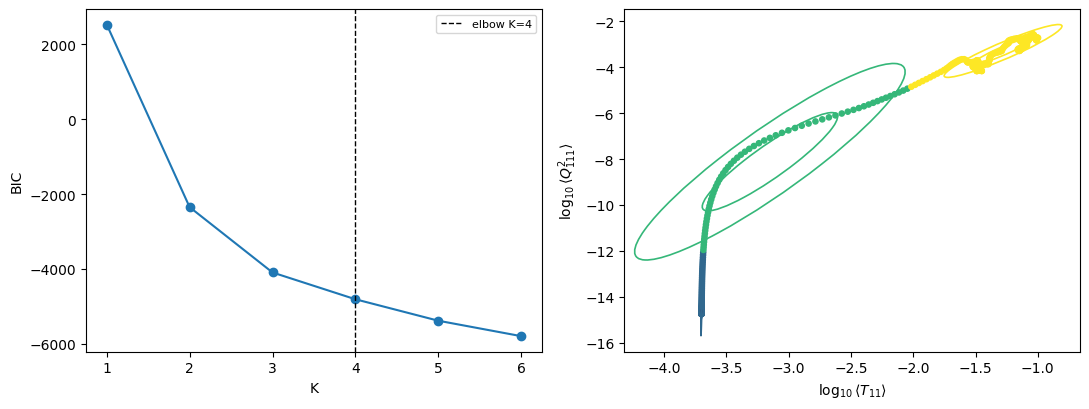

K=1: BIC=2449.2
K=2: BIC=-2195.6
K=3: BIC=-3651.0
K=4: BIC=-4460.7
K=5: BIC=-5002.5
K=6: BIC=-5549.8
elbow selects K=4 (BIC min would give K=6)


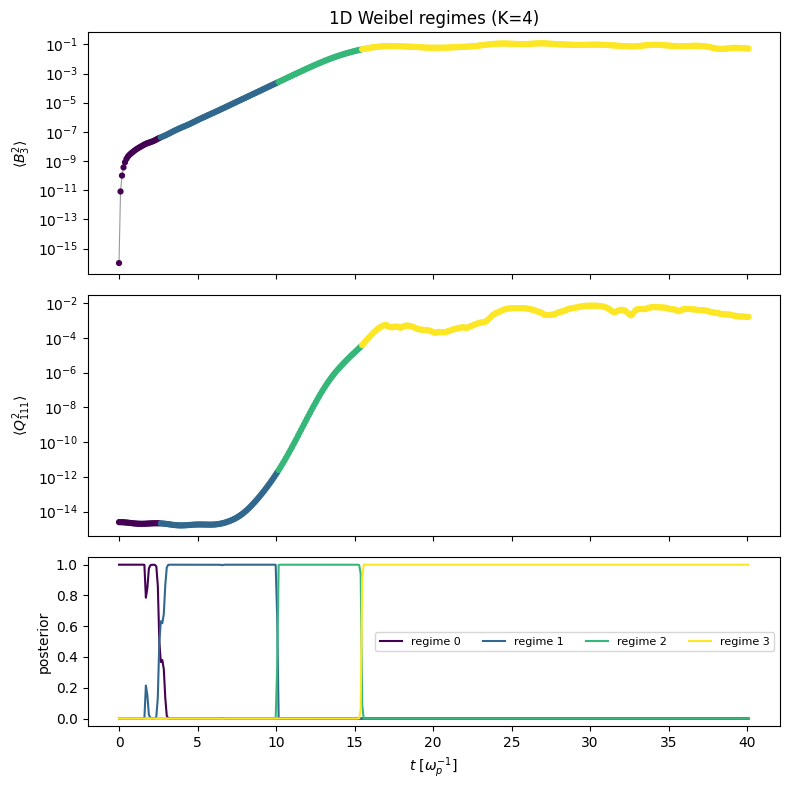

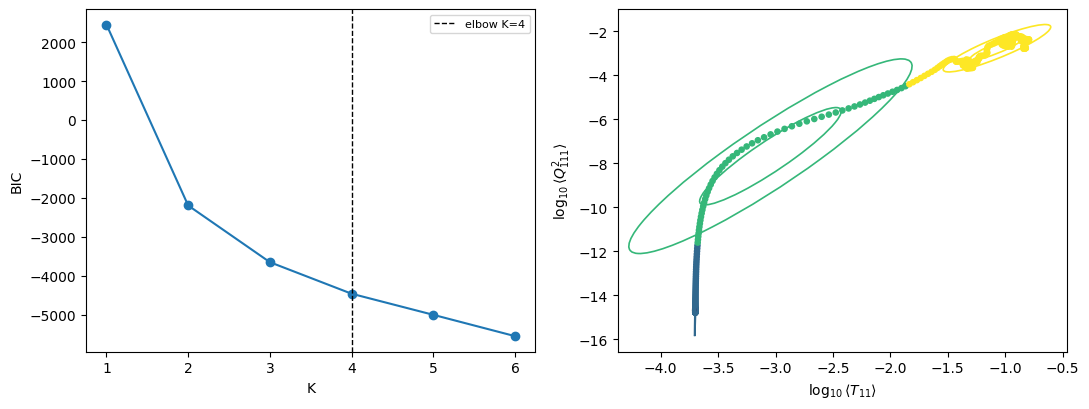

K=1: BIC=2903.8
K=2: BIC=-2613.4
K=3: BIC=-4527.7
K=4: BIC=-5252.7
K=5: BIC=-6251.3
K=6: BIC=-7029.4
elbow selects K=6 (BIC min would give K=6)


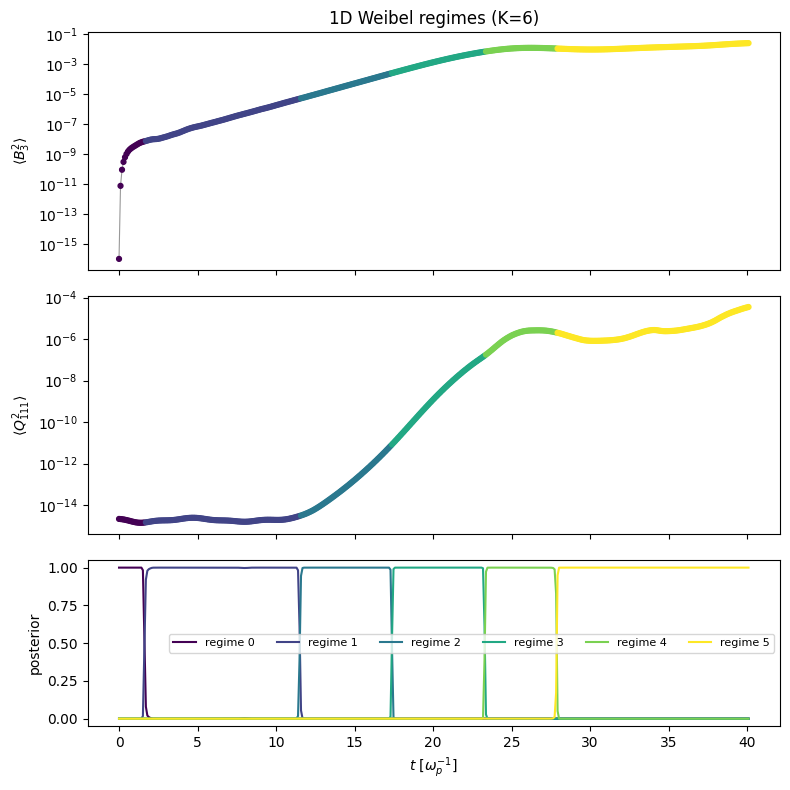

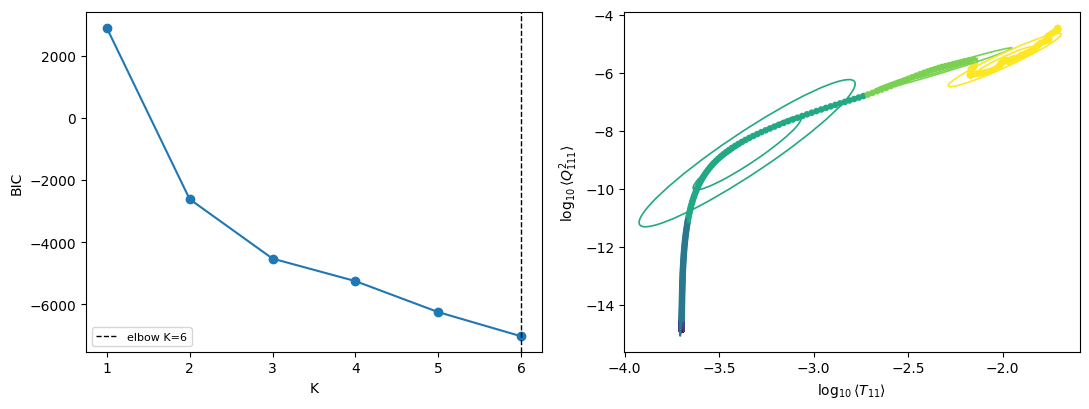

K=1: BIC=2621.2
K=2: BIC=-2357.5
K=3: BIC=-4244.3
K=4: BIC=-4918.5
K=5: BIC=-5671.3
K=6: BIC=-6085.6
elbow selects K=5 (BIC min would give K=6)


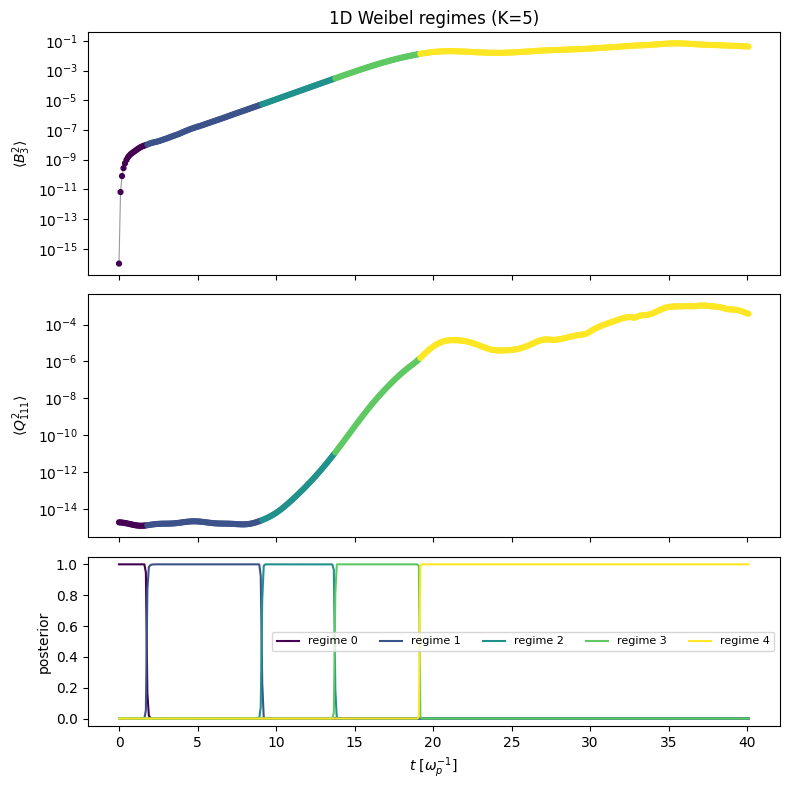

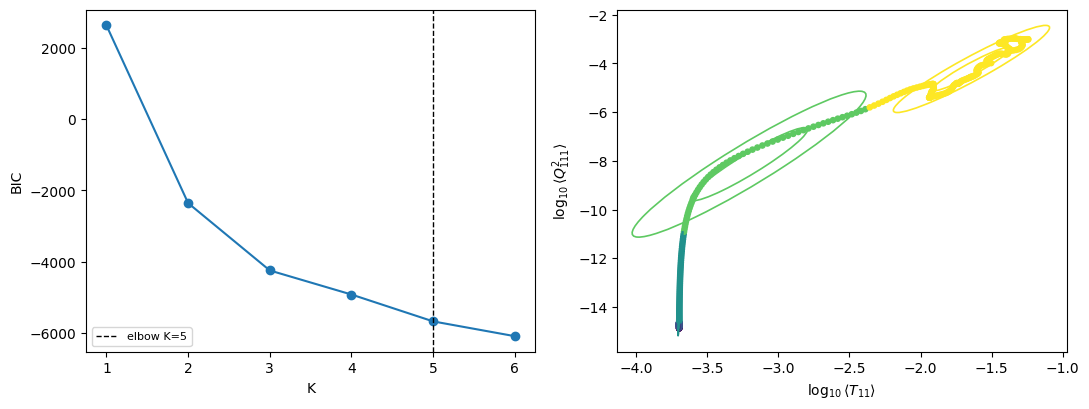

K=1: BIC=2486.9
K=2: BIC=-2050.2
K=3: BIC=-3603.4
K=4: BIC=-4175.5
K=5: BIC=-4850.5
K=6: BIC=-5297.1
elbow selects K=5 (BIC min would give K=6)


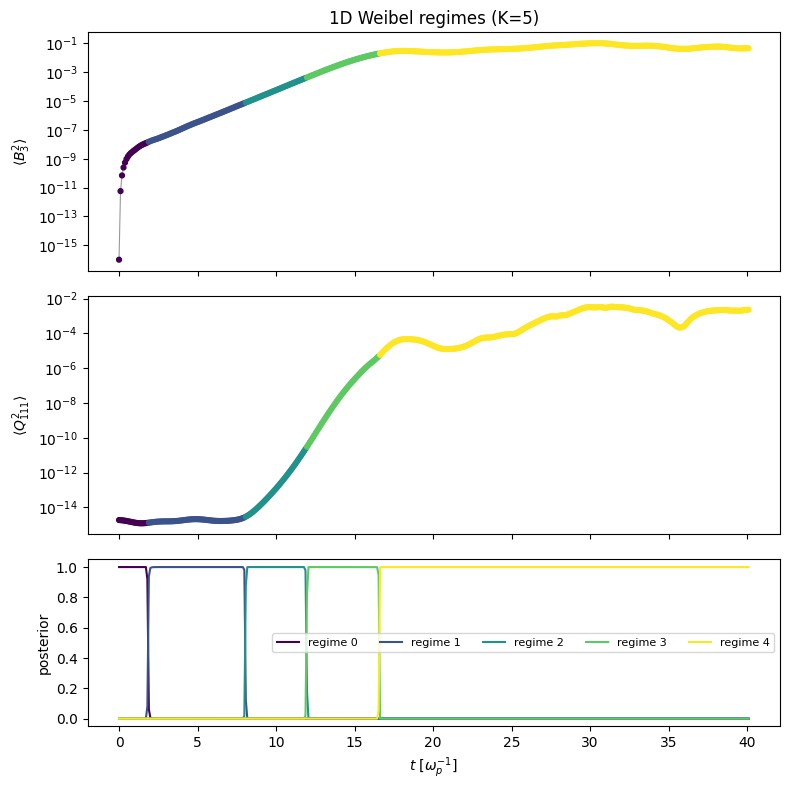

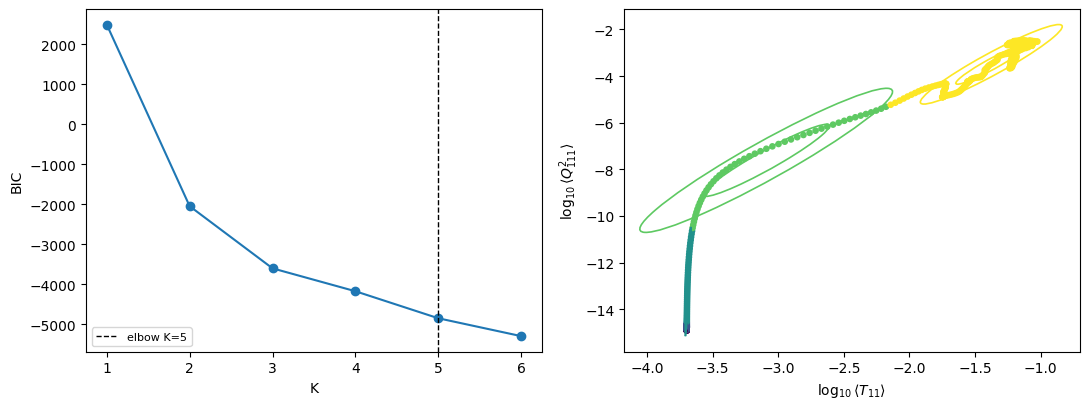

K=1: BIC=2409.0
K=2: BIC=-1859.0
K=3: BIC=-3199.2
K=4: BIC=-3857.0
K=5: BIC=-4543.2
K=6: BIC=-4984.6
elbow selects K=5 (BIC min would give K=6)


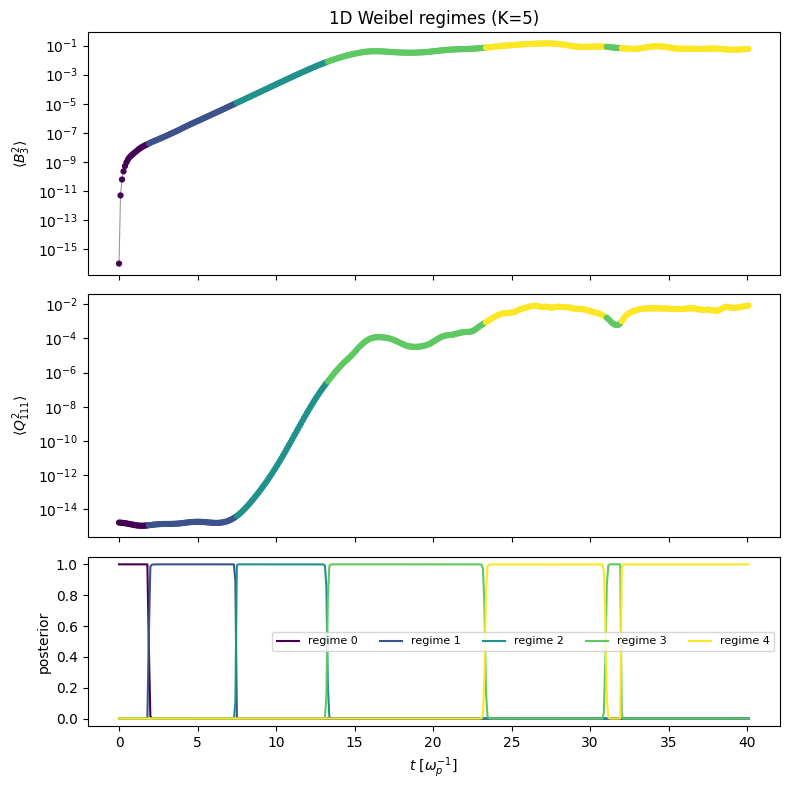

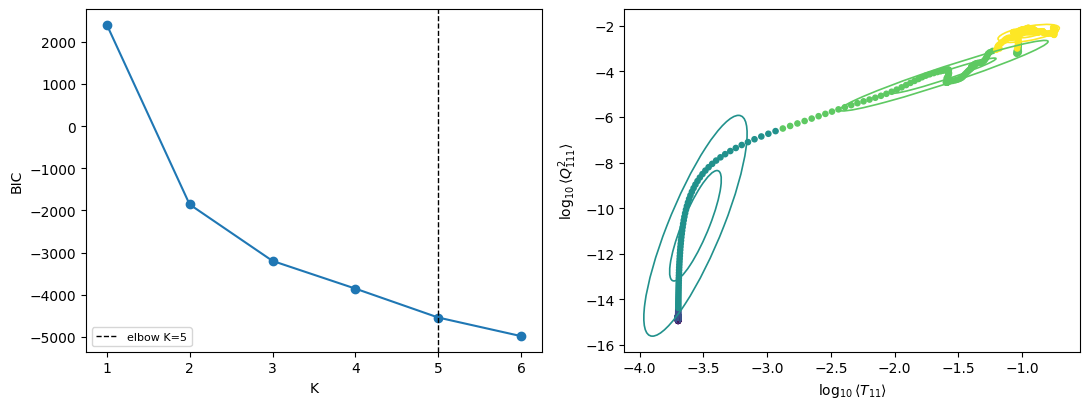

K=1: BIC=2989.6
K=2: BIC=-2358.4
K=3: BIC=-4299.1
K=4: BIC=-5128.0
K=5: BIC=-6276.4
K=6: BIC=-6764.7
elbow selects K=5 (BIC min would give K=6)


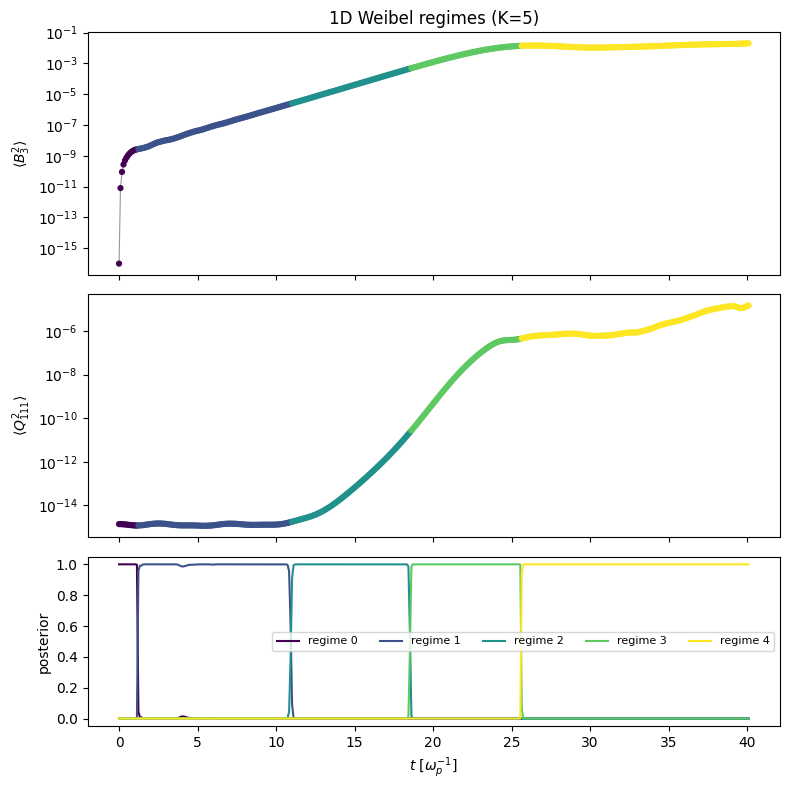

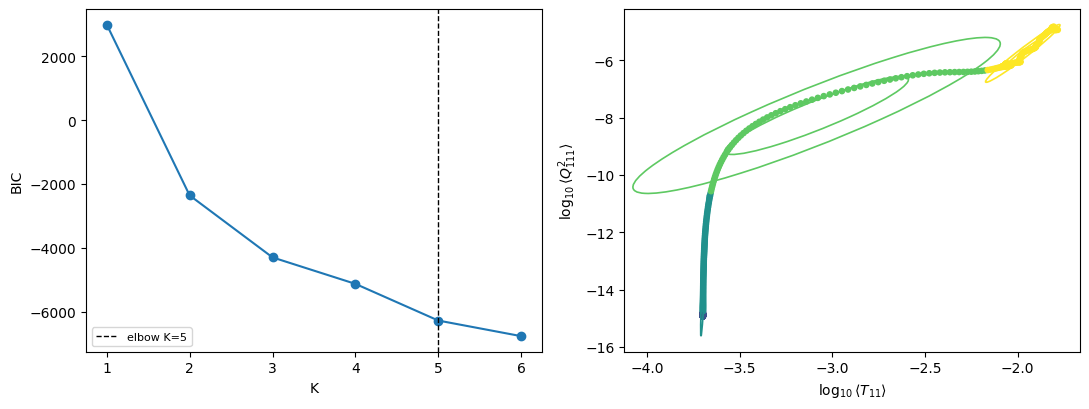

K=1: BIC=2739.3
K=2: BIC=-2040.9
K=3: BIC=-4092.3
K=4: BIC=-4715.3
K=5: BIC=-5793.1
K=6: BIC=-6307.3
elbow selects K=3 (BIC min would give K=6)


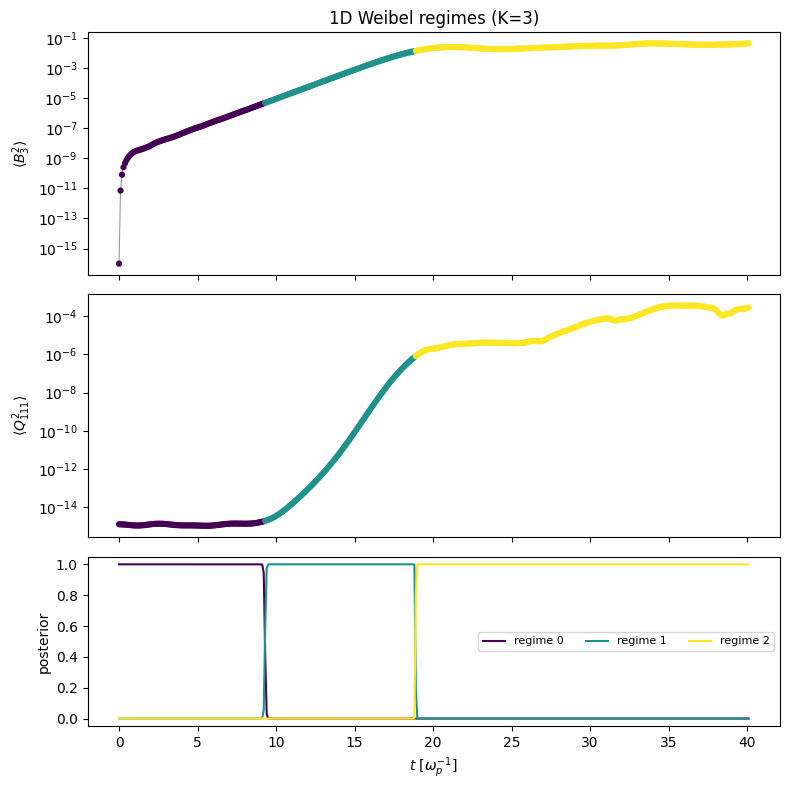

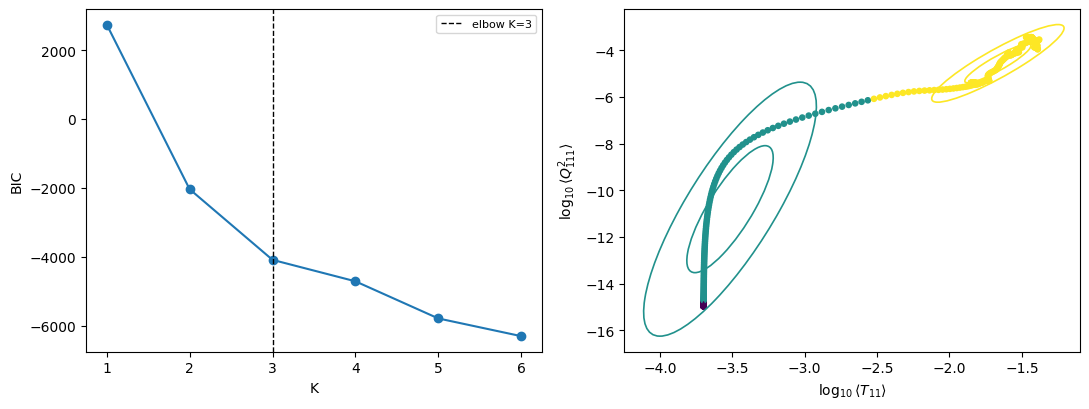

K=1: BIC=2579.2
K=2: BIC=-2143.0
K=3: BIC=-4003.9
K=4: BIC=-4566.8
K=5: BIC=-5455.8
K=6: BIC=-5860.1
elbow selects K=3 (BIC min would give K=6)


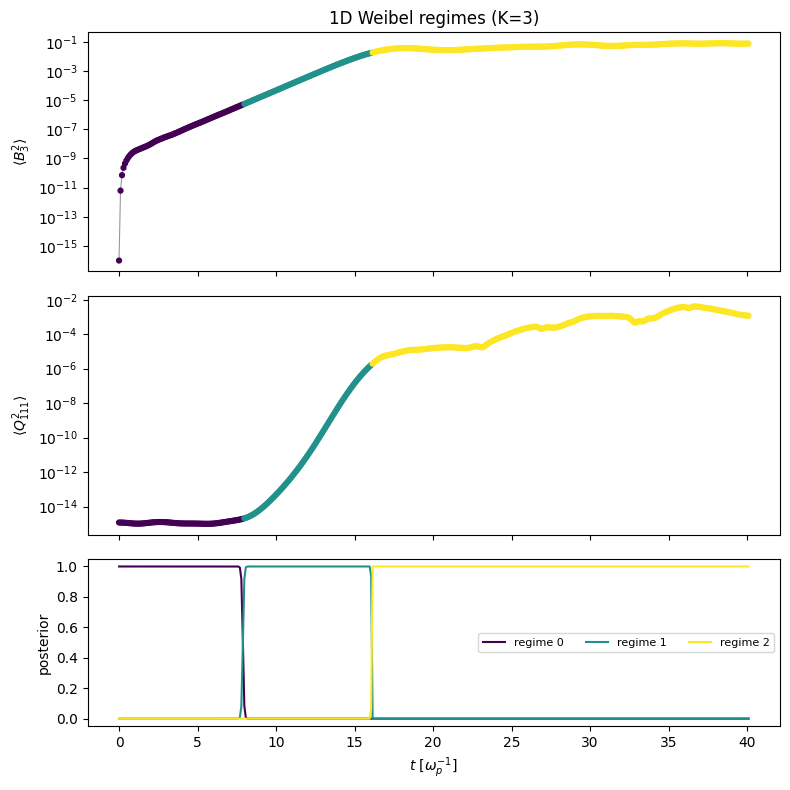

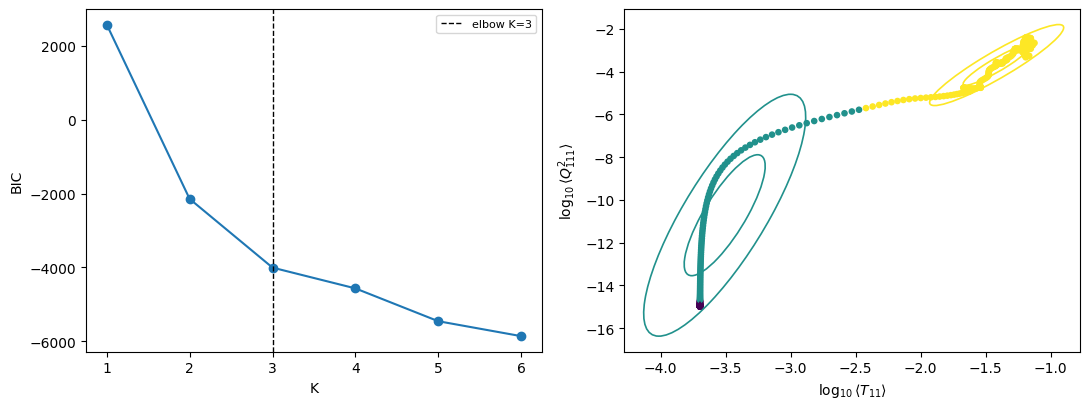

K=1: BIC=2499.9
K=2: BIC=-2106.7
K=3: BIC=-3890.6
K=4: BIC=-4338.1
K=5: BIC=-5025.9
K=6: BIC=-5406.7
elbow selects K=3 (BIC min would give K=6)


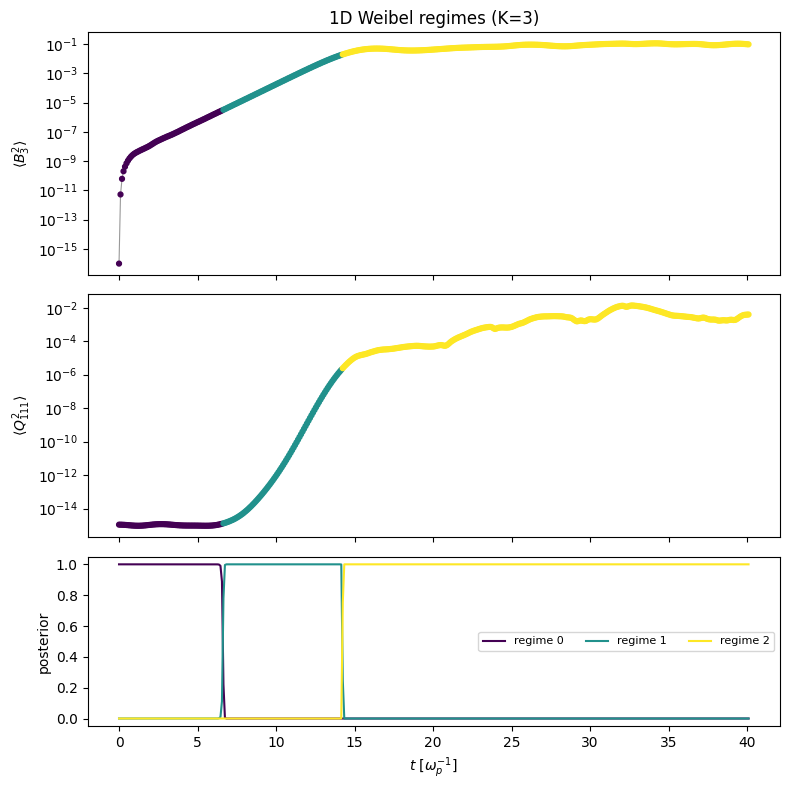

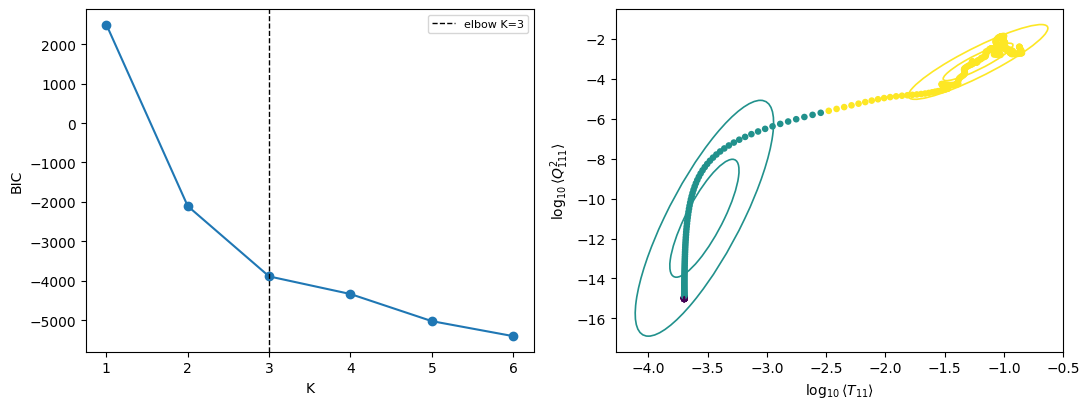

In [10]:
# Extract the features for each snapshot in time, and standardize them to have zero mean and unit variance

saturation_interval = {}  # Initialize saturation intervals for each dataset

for data_set in datasets:
    # if `datasets` is a single string (loop would iterate its characters), use the full string

    F = snapshot_features(data_set)
    scaler = StandardScaler().fit(F)
    Xs = scaler.transform(F)

    # Fit Gaussian Mixture Models for different values of K and compute the BIC for each model.
    # Select the best K using the elbow method based on the BIC values.
    bics, models = [], {}
    for k in KS:
        # Fit a Gaussian Mixture Model with k components to the standardized features Xs
        gm = GaussianMixture(n_components=k, covariance_type="full", n_init=20, random_state=SEED).fit(Xs)

        # Compute the Bayesian Information Criterion (BIC) for the fitted model and store it in the bics list
        bics.append(gm.bic(Xs))
        models[k] = gm
        print(f"K={k}: BIC={bics[-1]:.1f}")

    gains = -np.diff(bics)
    total = bics[0] - min(bics)  # Total gain in BIC from K=1 to the minimum BIC

    # Elbow method: select the smallest K such that the gain in BIC is less than ELBOW_FRAC * total gain
    k_best = next((list(KS)[i] for i, g in enumerate(gains) if g < ELBOW_FRAC * total), list(KS)[-1])
    print(f"elbow selects K={k_best} (BIC min would give K={list(KS)[int(np.argmin(bics))]})")

    # Choose the best model (the one with the selected K) and predict the labels for each snapshot in time
    gm = models[k_best]
    lab = gm.predict(Xs)
    order = np.argsort([time_array[lab == j].mean() if np.any(lab == j) else np.inf for j in range(k_best)])
    relabel = np.empty(k_best, int)
    relabel[order] = np.arange(k_best)
    labels = relabel[lab]

    # choose the last regime to be the saturated one and compute the time interval where the system is in saturation
    reg_q = np.array([F[labels == j, 3].mean() if np.any(labels == j) else -np.inf for j in range(k_best)])
    active = np.where(reg_q >= reg_q.max() - 2.0)[0]

    closure_t_min = float(time_array[np.isin(labels, active)].min())
    closure_iter_min = int(np.where(np.isin(labels, active))[0].min())
    closure_t_max = float(time_array[np.isin(labels, active)].max())
    closure_iter_max = int(np.where(np.isin(labels, active))[0].max())

    saturation_interval[data_set] = [(closure_t_min, closure_t_max), (closure_iter_min, closure_iter_max)]

    cmap = plt.get_cmap("viridis", k_best)
    fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True, height_ratios=[2, 2, 1.4])

    b3sq = 10.0 ** F[:, 0]
    ax[0].plot(time_array, b3sq, "-", color="0.6", lw=0.8)
    ax[0].scatter(time_array, b3sq, c=labels, cmap=cmap, vmin=-0.5, vmax=k_best - 0.5, s=12, zorder=3)
    ax[0].set_yscale("log")
    ax[0].set_ylabel(r"$\langle B_3^2\rangle$")
    ax[0].set_title(f"1D Weibel regimes (K={k_best})")

    qsq = 10.0 ** F[:, 3]
    ax[1].plot(time_array, qsq, "-", color="0.6", lw=0.8)
    ax[1].scatter(time_array, qsq, c=labels, cmap=cmap, vmin=-0.5, vmax=k_best - 0.5, s=12, zorder=3)
    ax[1].set_yscale("log")
    ax[1].set_ylabel(r"$\langle Q_{111}^2\rangle$")

    probs = gm.predict_proba(Xs)[:, order]
    for j in range(k_best):
        ax[2].plot(time_array, probs[:, j], color=cmap(j), label=f"regime {j}")
    ax[2].set_ylabel("posterior")
    ax[2].set_xlabel(r"$t\ [\omega_p^{-1}]$")
    ax[2].legend(fontsize=8, ncol=k_best)
    plt.tight_layout()
    fig.savefig(GMM_DIR / f"gmm_timeline_{data_set}.png", dpi=200)
    plt.show()
    plt.close(fig)

    # BIC + feature projection
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

    ax[0].plot(list(KS), bics, "o-")
    ax[0].axvline(k_best, color="k", ls="--", lw=1, label=f"elbow K={k_best}")
    ax[0].set_xlabel("K")
    ax[0].set_ylabel("BIC")
    ax[0].legend(fontsize=8)

    i, j = 2, 3  # log(B3^2) vs log(Q111^2)
    ax[1].scatter(F[:, i], F[:, j], c=labels, cmap=cmap, vmin=-0.5, vmax=k_best - 0.5, s=14)
    for comp in range(k_best):
        src = order[comp]
        mean = scaler.inverse_transform(gm.means_[src : src + 1])[0]
        cov = gm.covariances_[src][np.ix_([i, j], [i, j])] * np.outer(scaler.scale_[[i, j]], scaler.scale_[[i, j]])
        vals, vecs = np.linalg.eigh(cov)
        ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
        for ns in (1, 2):
            ax[1].add_patch(
                Ellipse(mean[[i, j]], 2 * ns * np.sqrt(vals[1]), 2 * ns * np.sqrt(vals[0]), angle=ang, fc="none", ec=cmap(comp), lw=1.2)
            )
    ax[1].set_xlabel(FEATURE_LABELS[i])
    ax[1].set_ylabel(FEATURE_LABELS[j])
    plt.tight_layout()
    fig.savefig(GMM_DIR / f"gmm_features_{data_set}.png", dpi=200)
    plt.show()
    plt.close(fig)


In [11]:
saturation_interval

{'dx0.1_dt0.095_200ppc_0.3vfl': [(22.04, 40.09), (232, 422)],
 'dx0.1_dt0.095_200ppc_0.4vfl': [(13.68, 40.09), (144, 422)],
 'dx0.1_dt0.095_200ppc_0.5vfl': [(13.965, 40.09), (147, 422)],
 'dx0.1_dt0.095_200ppc_0.6vfl': [(12.445, 40.09), (131, 422)],
 'dx0.1_dt0.095_600ppc_0.3vfl': [(23.56, 40.09), (248, 422)],
 'dx0.1_dt0.095_600ppc_0.4vfl': [(19.095, 40.09), (201, 422)],
 'dx0.1_dt0.095_600ppc_0.5vfl': [(16.72, 40.09), (176, 422)],
 'dx0.1_dt0.095_600ppc_0.6vfl': [(15.295, 40.09), (161, 422)],
 'dx0.1_dt0.095_1000ppc_0.3vfl': [(24.225, 40.09), (255, 422)],
 'dx0.1_dt0.095_1000ppc_0.4vfl': [(19.665, 40.09), (207, 422)],
 'dx0.1_dt0.095_1000ppc_0.5vfl': [(17.1, 40.09), (180, 422)],
 'dx0.1_dt0.095_1000ppc_0.6vfl': [(15.485, 40.09), (163, 422)],
 'dx0.1_dt0.095_1400ppc_0.3vfl': [(23.37, 40.09), (246, 422)],
 'dx0.1_dt0.095_1400ppc_0.4vfl': [(19.19, 40.09), (202, 422)],
 'dx0.1_dt0.095_1400ppc_0.5vfl': [(16.625, 40.09), (175, 422)],
 'dx0.1_dt0.095_1400ppc_0.6vfl': [(13.3, 40.09), (140, 4

# 2) LASSO Regression for Heat-Flux Closure

Goal: an explicit closure $Q_{111} \approx f(\text{lower moments, fields, gradients})$ valid in the saturation window found in section 1. Strategy: build a large library of physically motivated candidate terms, then let sparse regression select the few that matter.

The next cell builds that library: 4th-order finite-difference $x_1$-derivative stencils, a block-average ("weak form") filter, and hand-built *wildcard* features that a degree-2 polynomial expansion cannot reach on its own — 39 base features in total.

In [12]:
# Offset j -> coefficient for f[i+j]; 4th-order-accurate central stencils.
# (Denominator 12 folded in; final result divided by dx**order.)
FD_STENCILS: dict[int, dict[int, float]] = {
    1: {2: -1 / 12, 1: 8 / 12, -1: -8 / 12, -2: 1 / 12},  # d/dx1
    2: {2: -1 / 12, 1: 16 / 12, 0: -30 / 12, -1: 16 / 12, -2: -1 / 12},  # d2/dx1^2
    3: {2: 1 / 2, 1: -2 / 2, -1: 2 / 2, -2: -1 / 2},  # d3/dx1^3
    4: {2: 1, 1: -4, 0: 6, -1: -4, -2: 1},  # d4/dx1^4
}


def d_dx(arr: np.ndarray, order: int = 1, dx: float = DX) -> np.ndarray:
    """`order`-th centered x1 derivative (periodic, 4th-order accurate)."""
    out = sum(c * np.roll(arr, -j, axis=1) for j, c in FD_STENCILS[order].items())
    return out / dx**order


def block_average(arr: np.ndarray, k: int) -> np.ndarray:
    """Non-overlapping k-cell box filter along x1 ("weak form" test function)."""
    if k == 1:
        return arr
    n_t, n1 = arr.shape
    return arr.reshape(n_t, n1 // k, k).mean(axis=2)


def add_gradients(d: dict[str, np.ndarray], keys: list[str], orders: tuple[int, ...] = (1,)) -> dict[str, np.ndarray]:
    # Derivatives are saved as d{order}_{key}, e.g. d1_n, d2_T11, etc.
    for k in keys:
        for m in orders:
            d[f"d{m}_{k}"] = d_dx(d[k].astype(np.float64), m, DX).astype(np.float32)
    return d


# Wildcards: hand-built terms added to the feature library.
WILDCARDS: dict[str, callable] = {
    "vfl1^3": lambda d: d["vfl1"].astype(np.float64) ** 3,  # third power of velocity
    "sqrtT11": lambda d: np.sqrt(np.abs(d["T11"].astype(np.float64))),  # thermal velocity proxy (poly gives sqrt_T11*T11 = T^1.5)
    "T11_over_n": lambda d: d["T11"].astype(np.float64) / (d["n"] + 1e-12),  # ratios are unreachable via poly products
}

# 36 features: 8 base + 7*4 derivatives, plus the wildcards
FEATURES = [
    "n",
    "vfl1",
    "vfl2",
    "vfl3",
    "b3",
    "e1",
    "T11",
    "P11",
    # First derivatives
    "d1_n",
    "d1_T11",
    "d1_P11",
    "d1_vfl1",
    "d1_vfl2",
    "d1_b3",
    "d1_e1",
    # Second derivatives
    "d2_n",
    "d2_T11",
    "d2_P11",
    "d2_vfl1",
    "d2_vfl2",
    "d2_b3",
    "d2_e1",
    # Third derivatives
    "d3_n",
    "d3_T11",
    "d3_P11",
    "d3_vfl1",
    "d3_vfl2",
    "d3_b3",
    "d3_e1",
    # Fourth derivatives
    "d4_n",
    "d4_T11",
    "d4_P11",
    "d4_vfl1",
    "d4_vfl2",
    "d4_b3",
    "d4_e1",
] + list(WILDCARDS)
GRADIENT_KEYS = ["n", "T11", "P11", "vfl1", "vfl2", "b3", "e1"]
GRADIENT_ORDERS = (1, 2, 3, 4)


def build_design_matrix(
    sim_labels: list[str],
    time_interval: tuple[float, float],
    feature_names: list[str],
    target: str = "Q111",
    block: int = 1,
    n_workers: int = 8,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Stack (X, y, t) over simulations and species, restricted to `time_interval`.

    Gradients and wildcards are computed on the full grid, then everything is
    block-averaged (weak form). Only snapshots with index in [iter_min, iter_max)
    are kept, where iter = int(t / DT_DUMP).

    Returns
    -------
    X : (n_samples, n_features) float32
    y : (n_samples,) float32 -- target
    t : (n_samples,) float32 -- simulation time of each sample
    """
    iter_min, iter_max = int(time_interval[0] / DT_DUMP), int(time_interval[1] / DT_DUMP)
    sl = slice(iter_min, iter_max)

    X_parts, y_parts, t_parts = [], [], []
    for lab in sim_labels:
        d = add_gradients(
            load_all(
                sim_label=lab, species=ELECTRON_SPECIES, n_workers=n_workers, cache_dir=CACHE_DIR, simulations=SIMS, fields=FIELD_KEYS
            ),
            GRADIENT_KEYS,
            GRADIENT_ORDERS,
        )
        for name, fn in WILDCARDS.items():
            d[name] = np.asarray(fn(d), dtype=np.float64)  # wildcards see base fields + gradients
        feats = [block_average(d[f][sl].astype(np.float64), block) for f in feature_names]

        y = block_average(d[target][sl].astype(np.float64), block)
        n_t, n1 = y.shape

        X_parts.append(np.stack([f.ravel() for f in feats], axis=1))
        y_parts.append(y.ravel())
        t_parts.append(np.repeat(np.arange(iter_min, iter_min + n_t, dtype=np.float32) * DT_DUMP, n1))

    return (
        np.concatenate(X_parts).astype(np.float32),
        np.concatenate(y_parts).astype(np.float32),
        np.concatenate(t_parts).astype(np.float32),
    )

In [13]:
TARGET = "Q111"


# Suffle and divide the labels for train and test
def suffle_divide_labels(sim_labels: list[str], train_frac: float = 0.8, seed: int = 42) -> tuple[list[str], list[str]]:
    rng = np.random.default_rng(seed)
    shuffled_labels = rng.permutation(sim_labels)
    n_train = int(len(shuffled_labels) * train_frac)
    train_labels = shuffled_labels[:n_train].tolist()
    test_labels = shuffled_labels[n_train:].tolist()
    return train_labels, test_labels


train_labels, test_labels = suffle_divide_labels(sim_labels, train_frac=0.7, seed=SEED)

X_train_sims = []
y_train_sims = []
t_train_sims = []

for labels in train_labels:
    print(labels)
    X_train, y_train, t_train = build_design_matrix(
        [labels],
        saturation_interval[labels][0],
        FEATURES,
        target=TARGET,
        block=1,
        n_workers=8,
    )
    X_train_sims.append(X_train)
    y_train_sims.append(y_train)
    t_train_sims.append(t_train)

X_train = np.concatenate(X_train_sims, axis=0)
y_train = np.concatenate(y_train_sims, axis=0)

X_test_sims = []
y_test_sims = []
t_test_sims = []

for labels in test_labels:
    print(labels)
    X_test, y_test, t_test = build_design_matrix(
        [labels],
        saturation_interval[labels][0],
        FEATURES,
        target=TARGET,
        block=1,
        n_workers=8,
    )
    X_test_sims.append(X_test)
    y_test_sims.append(y_test)
    t_test_sims.append(t_test)

X_test = np.concatenate(X_test_sims, axis=0)
y_test = np.concatenate(y_test_sims, axis=0)


groups_train_parts = []
group_offset = 0

for t_sim in t_train_sims:
    _, groups_sim = np.unique(t_sim, return_inverse=True)
    groups_train_parts.append(groups_sim + group_offset)
    group_offset += groups_sim.max() + 1

groups_train = np.concatenate(groups_train_parts)

dx0.1_dt0.095_600ppc_0.3vfl
dx0.1_dt0.095_1800ppc_0.6vfl
dx0.1_dt0.095_600ppc_0.5vfl
dx0.1_dt0.095_200ppc_0.5vfl
dx0.1_dt0.095_1400ppc_0.4vfl
dx0.1_dt0.095_1800ppc_0.3vfl
dx0.1_dt0.095_200ppc_0.6vfl
dx0.1_dt0.095_1000ppc_0.6vfl
dx0.1_dt0.095_1000ppc_0.5vfl
dx0.1_dt0.095_1000ppc_0.3vfl
dx0.1_dt0.095_200ppc_0.3vfl
dx0.1_dt0.095_1400ppc_0.3vfl
dx0.1_dt0.095_600ppc_0.6vfl
dx0.1_dt0.095_600ppc_0.4vfl
dx0.1_dt0.095_1800ppc_0.5vfl
dx0.1_dt0.095_1800ppc_0.4vfl
dx0.1_dt0.095_1400ppc_0.5vfl
dx0.1_dt0.095_1000ppc_0.4vfl
dx0.1_dt0.095_200ppc_0.4vfl
dx0.1_dt0.095_1400ppc_0.6vfl


In [14]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

# Normalization
x_scaler = StandardScaler().fit(X_train)
X_train_scaled = x_scaler.transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

In [15]:
cv_splits = list(GroupKFold(n_splits=5).split(X_train_scaled, y_train, groups=groups_train))

# Fit a Lasso regression model with cross-validation to find the best regularization parameter
lasso = LassoCV(cv=cv_splits, random_state=42, n_jobs=-1, max_iter=10000)
lasso.fit(X_train_scaled.astype(np.float64), y_train.astype(np.float64))

# Evaluate the model on the test set
y_test_pred = lasso.predict(X_test_scaled)
r2_test = r2_score(y_test, y_test_pred)

print(f"LassoCV: alpha = {lasso.alpha_:.3e}, {np.count_nonzero(lasso.coef_)} nonzero terms, test R^2 = {r2_test:.4f}")

LassoCV: alpha = 3.163e-05, 262 nonzero terms, test R^2 = 0.9195


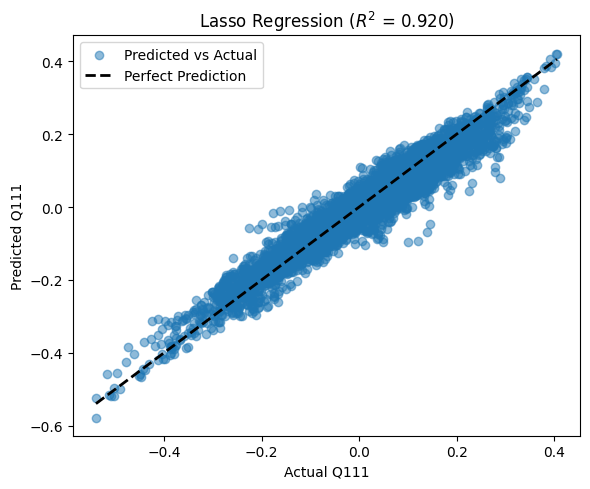

In [16]:
# Real vs predicted Q111 for Lasso (left) and Ridge (right) on the test set
fig, axes = plt.subplots(1, 1, figsize=(6, 5), sharex=True, sharey=True)
for ax, pred, name, r2 in ((axes, y_test_pred, "Lasso", r2_test),):
    ax.scatter(y_test, pred, alpha=0.5, label="Predicted vs Actual")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2, label="Perfect Prediction")
    ax.set_xlabel("Actual Q111")
    ax.set_title(f"{name} Regression ($R^2$ = {r2:.3f})")
    ax.legend()
axes.set_ylabel("Predicted Q111")
plt.tight_layout()
plt.savefig(FIG_DIR / "lasso_true_vs_predicted_test.png", dpi=200)
plt.show()

In [17]:
def plot_closure_map(model=lasso, poly=poly, scaler=x_scaler, sim="test-weibel", feats=FEATURES, block=1):
    """(t, x1) maps of true vs LASSO-predicted TARGET for one sim/species."""
    t0, t1 = saturation_interval[sim][0]
    X, y, t = build_design_matrix([sim], (t0, t1), feats, target=TARGET, block=block)
    n_t = len(np.unique(t))  # rows are raveled (n_t, n1) row-major
    true_map = y.reshape(n_t, -1)

    X_scaled = scaler.transform(poly.transform(X))  # same poly + scaler used for X_train/X_test
    pred_map = model.predict(X_scaled).reshape(true_map.shape)

    ext = [0, true_map.shape[1] * block * DX, float(t[0]), float(t[-1])]
    fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
    vmax = np.percentile(np.abs(true_map), 99)
    print(f"vmax = {vmax:.3e}")
    for a, arr, title in ((ax[0], true_map, "PIC (true)"), (ax[1], pred_map, f"{model.__class__.__name__} closure")):
        im = a.imshow(arr, origin="lower", aspect="auto", cmap="seismic", vmin=-vmax, vmax=vmax, extent=ext)
        a.set_xlabel(r"$x_1\ [c/\omega_p]$")
        a.set_title(rf"${TARGET}$: {title}")
        plt.colorbar(im, ax=a, fraction=0.046, pad=0.04)
    ax[0].set_ylabel(r"$t\ [\omega_p^{-1}]$")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"lasso_map_{sim}.png", dpi=200)
    return fig


vmax = 1.273e-01


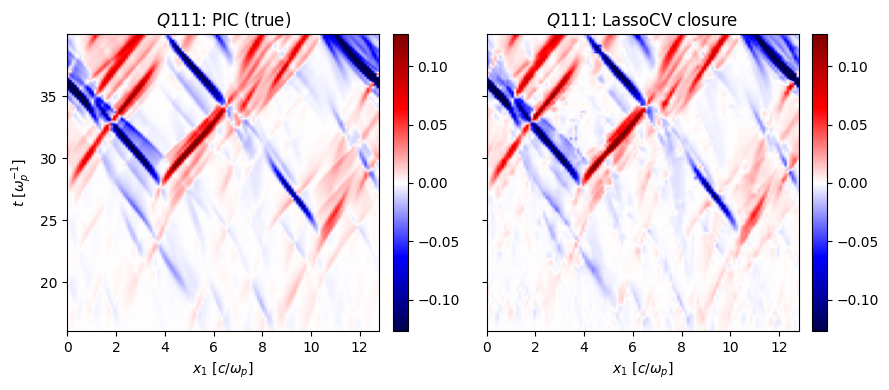

In [18]:
fig = plot_closure_map(sim=test_labels[0])

In [19]:
def lasso_terms(model=lasso, poly=poly, scaler=x_scaler, feats=FEATURES):
    """Nonzero LASSO terms, ordered by importance (|scaled coef|)."""
    df = pd.DataFrame({
        "Term": poly.get_feature_names_out(feats),
        "Coef (scaled)": model.coef_,
        "Coef (physical)": model.coef_ / scaler.scale_,  # undo StandardScaler
    })
    df = df[df["Coef (scaled)"] != 0]
    return df.sort_values(by="Coef (scaled)", key=np.abs, ascending=False)


terms_df = lasso_terms(model=lasso, poly=poly, scaler=x_scaler, feats=FEATURES)
print(terms_df)

              Term  Coef (scaled)  Coef (physical)
84        vfl1 P11   4.480549e-02     2.405181e+00
75        n vfl1^3  -1.195232e-02    -1.254402e+00
302    P11 d2_vfl1   6.328525e-03     6.058328e-03
57       n d2_vfl1   4.055294e-03     4.537182e-04
71       n d4_vfl1   3.399411e-03     1.988693e-06
..             ...            ...              ...
768   d4_n d4_vfl2   1.349973e-06     2.800495e-14
562   d2_T11 d4_e1  -1.310751e-06    -8.681351e-09
206       b3 d2_e1   9.574905e-07     1.198345e-05
590  d2_vfl1 d2_b3   8.426437e-07     3.605153e-08
526      d2_n d3_n   4.248163e-07     8.612655e-12

[262 rows x 3 columns]


In [20]:
def reconstruct_target(n_terms, model=lasso, poly=poly, scaler=x_scaler, sim=test_labels[0], feats=FEATURES, block=1):
    """Reconstruct TARGET on `sim` using only the `n_terms` most important LASSO terms.

    Importance = |scaled coefficient|, same ranking as `lasso_terms`. All other
    coefficients are zeroed; the intercept is always kept.

    Returns (y_true, y_rec, t, kept_names).
    """
    t0, t1 = saturation_interval[sim][0]
    X, y, t = build_design_matrix([sim], (t0, t1), feats, target=TARGET, block=block)
    X_scaled = scaler.transform(poly.transform(X))

    nz = np.flatnonzero(model.coef_)
    order = nz[np.argsort(np.abs(model.coef_[nz]))[::-1]]  # nonzero terms, most important first
    keep = order[:n_terms]

    y_rec = X_scaled[:, keep] @ model.coef_[keep] + model.intercept_

    kept_names = list(poly.get_feature_names_out(feats)[keep])
    shown = ", ".join(kept_names[:5]) + (", ..." if len(kept_names) > 5 else "")
    print(f"{sim}: {len(keep)}/{len(nz)} terms -> R^2 = {r2_score(y, y_rec):.5f}  [{shown}]")
    return y, y_rec, t, kept_names


# How fast does the reconstruction converge to the full model as terms are added?
for n in (1, 2, 3, 5, 10, 25, np.count_nonzero(lasso.coef_)):  # last entry = full LASSO support
    y_true, y_rec, t_rec, kept = reconstruct_target(model=lasso, n_terms=n)

dx0.1_dt0.095_1800ppc_0.5vfl: 1/262 terms -> R^2 = 0.70168  [vfl1 P11]
dx0.1_dt0.095_1800ppc_0.5vfl: 2/262 terms -> R^2 = 0.93340  [vfl1 P11, n vfl1^3]
dx0.1_dt0.095_1800ppc_0.5vfl: 3/262 terms -> R^2 = 0.94174  [vfl1 P11, n vfl1^3, P11 d2_vfl1]
dx0.1_dt0.095_1800ppc_0.5vfl: 5/262 terms -> R^2 = 0.93945  [vfl1 P11, n vfl1^3, P11 d2_vfl1, n d2_vfl1, n d4_vfl1]
dx0.1_dt0.095_1800ppc_0.5vfl: 10/262 terms -> R^2 = 0.94369  [vfl1 P11, n vfl1^3, P11 d2_vfl1, n d2_vfl1, n d4_vfl1, ...]
dx0.1_dt0.095_1800ppc_0.5vfl: 25/262 terms -> R^2 = 0.95958  [vfl1 P11, n vfl1^3, P11 d2_vfl1, n d2_vfl1, n d4_vfl1, ...]
dx0.1_dt0.095_1800ppc_0.5vfl: 262/262 terms -> R^2 = 0.96227  [vfl1 P11, n vfl1^3, P11 d2_vfl1, n d2_vfl1, n d4_vfl1, ...]


In [21]:
def reconstruct_target_physical(n_terms, model=lasso, poly=poly, scaler=x_scaler, sim=test_labels[0], feats=FEATURES):
    """Reconstruct TARGET on the full (t, x1) grid of `sim` as an explicit physical
    equation: sum the raw PIC diagnostics (products like vfl1*P11) weighted by
    their physical coefficients.

        Q111 ~ sum_j (c_j / sigma_j) * term_j(n, vfl1, P11, ...) + b_eff

    No poly/scaler transform at prediction time -- this is the closure as a fluid
    code would evaluate it. b_eff absorbs the StandardScaler centering of the kept
    terms, so it depends on which terms are kept.

    Returns the reconstructed diagnostic, shaped (n_t, nx) over the full sim time.
    """
    # Full-grid diagnostics: base fields + gradients + wildcards, same as build_design_matrix
    d = add_gradients(
        load_all(sim, ELECTRON_SPECIES, cache_dir=CACHE_DIR, simulations=SIMS, fields=FIELD_KEYS), GRADIENT_KEYS, GRADIENT_ORDERS
    )
    for name, fn in WILDCARDS.items():
        d[name] = np.asarray(fn(d), dtype=np.float64)

    def eval_factor(factor):
        """One factor of a PolynomialFeatures name -> (n_t, nx) array."""
        if factor in d:  # plain feature or wildcard (wildcard names may themselves contain "^")
            return d[factor].astype(np.float64)
        base, _, power = factor.rpartition("^")  # power suffix added by poly, e.g. "P11^2" or "vfl1^3^2"
        return d[base].astype(np.float64) ** int(power)

    names = poly.get_feature_names_out(feats)
    nz = np.flatnonzero(model.coef_)
    keep = nz[np.argsort(np.abs(model.coef_[nz]))[::-1]][:n_terms]  # most important first

    coef_phys = model.coef_ / scaler.scale_
    b_eff = model.intercept_ - np.sum(model.coef_[keep] * scaler.mean_[keep] / scaler.scale_[keep])

    recon = np.full(d["n"].shape, b_eff, dtype=np.float64)
    for j in keep:
        term_value = np.ones_like(recon)
        for factor in names[j].split(" "):
            term_value *= eval_factor(factor)
        recon += coef_phys[j] * term_value

    eq = " + ".join(f"({coef_phys[j]:+.3e})*{names[j]}" for j in keep)
    print(f"{TARGET} ~ {eq} + ({b_eff:+.3e})")
    return recon


new_diagnostics = reconstruct_target_physical(model=lasso, n_terms=2)

Q111 ~ (+2.405e+00)*vfl1 P11 + (-1.254e+00)*n vfl1^3 + (-1.569e-04)


In [22]:
data = load_all(test_labels[0], ["electrons-up", "electrons-down"], simulations=SIMS, cache_dir=CACHE_DIR, fields=FIELD_KEYS)

In [23]:
FVU = (((new_diagnostics - data["Q111"]) ** 2) / np.var(data["Q111"])).mean()
print(f"Fraction of Variance Unexplained of the reconstructed Q111: {100 * FVU}")

Fraction of Variance Unexplained of the reconstructed Q111: 6.653725773310685


Sparse model discovery following [Alves & Fiuza, PRResearch 4, 033192 (2022)](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.4.033192): a 1-by-1 sequentially-thresholded least-squares (STLSQ) elimination path across K folds gives the best $M$-term model for every $M$, the accuracy-vs-complexity Pareto front, and the stability of the discovered model form.

In [24]:
# This code was adapted from Alves and Fiuza (2022), "Data-driven discovery of reduced plasma physics models from fully kinetic simulations"
def plot_pareto_front_analysis(regression_results, pareto_pos=None):
    plt.figure(figsize=(12, 5))
    if pareto_pos is not None:
        plt.axvline(x=pareto_pos, c="k", ls="--", lw=1)
        # plt.axvline(x=2, c = 'k', ls = '--', lw=1)
    plt.scatter(
        regression_results["num_non_zero_terms"],
        regression_results["mse_train"] / regression_results["error_norm"],
        label=r"$E[\epsilon_{train}^2]$",
        facecolors="None",
        edgecolors="C1",
        s=60,
    )

    plt.scatter(
        regression_results["num_non_zero_terms"],
        regression_results["mse_test"] / regression_results["error_norm"],
        label=r"$E[\epsilon_{test}^2]$",
        facecolors="C3",
        s=15,
    )

    plt.xlabel(r"$\#$ nonzero terms")
    plt.ylabel(r"$E[\epsilon^2]$")
    plt.yscale("log")
    #     plt.ylim(5e-2,5)
    plt.xlim(-1, 30.5)
    plt.xticks(range(0, 32, 2))
    plt.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "pareto_front_analysis.png", dpi=200)


def STLS_1by1(X, y, xi=None):
    """Sequentially thresholded least-squares"""
    m, d = X.shape

    if np.all(xi is None):
        xi = np.linalg.lstsq(X, y, rcond=None)[0]

    lam = np.min(np.abs(xi[np.nonzero(xi)]))

    big_coefs = np.abs(xi) > lam
    small_coefs = np.logical_not(big_coefs)
    xi[small_coefs] = 0

    num_relevant = sum(big_coefs)
    if num_relevant == 0:
        return np.zeros(d), lam

    else:
        xi[big_coefs] = np.linalg.lstsq(X[:, big_coefs], y, rcond=None)[0]
        return xi, lam


def Kfold_STLS_regression__1by1(Theta, Y, K_folds=10, normalize_Theta=True):
    if normalize_Theta:
        Theta_Norm = np.sqrt(np.var(Theta, axis=0))
        Theta_Norm[0] = 1
    else:
        Theta_Norm = 1

    # error_Norm = np.mean(Y**2) # normalize errors to typical values of Y
    error_Norm = np.var(Y)  # normalize errors to typical values of Y

    kf = KFold(n_splits=K_folds, random_state=8, shuffle=True)
    kf.get_n_splits(Theta)

    # Range of regularization parameters for STLS regression
    n_terms = Theta.shape[-1]

    n_iters = n_terms
    lamdas = np.zeros(n_terms)
    coefficients_evol = np.zeros((K_folds, n_iters, n_terms))
    mse_train = np.zeros((K_folds, n_iters))
    mse_test = np.zeros((K_folds, n_iters))

    number_non_zero_terms = np.zeros((K_folds, n_iters))

    k = 0
    for train_index, test_index in kf.split(Theta):
        print("K-fold #", k)
        Theta_train, Theta_test = Theta[train_index], Theta[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]

        STLS_coefs = None
        for i in range(n_iters):
            STLS_coefs, lamdas[i] = STLS_1by1(X=Theta_train / Theta_Norm, y=Y_train[:, 0], xi=STLS_coefs)

            coefficients_evol[k, i, :] = STLS_coefs / Theta_Norm

            mse_train[k, i] = np.mean((Y_train[:, 0] - np.dot(Theta_train / Theta_Norm, STLS_coefs)) ** 2)
            mse_test[k, i] = np.mean((Y_test[:, 0] - np.dot(Theta_test / Theta_Norm, STLS_coefs)) ** 2)

        number_non_zero_terms[k, :] = [np.sum(np.abs(coefficients_evol[k, i, :]) > 0) for i in range(n_iters)]

        k += 1

    regression_results = {}
    regression_results["coeff_evol"] = coefficients_evol
    regression_results["num_non_zero_terms"] = number_non_zero_terms
    regression_results["mse_test"] = mse_test
    regression_results["mse_train"] = mse_train
    regression_results["error_norm"] = error_Norm
    regression_results["K"] = K_folds
    regression_results["lamdas"] = lamdas

    return regression_results


def LS_estimation_for_given_sparsity_pattern(Theta, Y, description, sparsity_pattern):
    # Final unbaised regression on full data
    final_Xi = np.dot(np.linalg.pinv(Theta[:, sparsity_pattern]), Y[:, 0])
    print("Nonzero terms:", np.array(description)[sparsity_pattern])
    print("Mean Coefficient values (on full data):", final_Xi)

    return final_Xi


def discovered_Mterm_models(regression_results, description, M=1):
    unique_Mterm_models = np.unique(regression_results["coeff_evol"][(regression_results["num_non_zero_terms"][:, :] == M)], axis=0)
    idx_non_zero_coefs_Mterm_models = np.sum(unique_Mterm_models**2, axis=0) > 0

    plt.figure(figsize=(6, 5))
    max_abs_coef = np.max(np.abs(unique_Mterm_models))
    plt.imshow(
        unique_Mterm_models[:, idx_non_zero_coefs_Mterm_models].T,
        origin="lower",
        cmap="RdBu_r",
        aspect="auto",
        vmin=-1.05 * max_abs_coef,
        vmax=1.05 * max_abs_coef,
    )

    # plt.yticks(range(sum(idx_non_zero_coefs_Mterm_models)), np.array(description)[idx_non_zero_coefs_Mterm_models], rotation='0')
    description_2 = [r"$" + descr + "$" for descr in description]
    plt.yticks(range(sum(idx_non_zero_coefs_Mterm_models)), np.array(description_2)[idx_non_zero_coefs_Mterm_models], rotation=0)
    plt.xlabel(str(M) + " term models")
    plt.ylabel("terms")
    num_unique_models = unique_Mterm_models.shape[0]
    plt.xlim(-0.5, num_unique_models - 0.5)
    plt.xticks(range(num_unique_models), range(1, num_unique_models + 1))
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"discovered_{M}term_models.png", dpi=200)

K-fold # 0
K-fold # 1
K-fold # 2
K-fold # 3
K-fold # 4
K-fold # 5
K-fold # 6
K-fold # 7
K-fold # 8
K-fold # 9


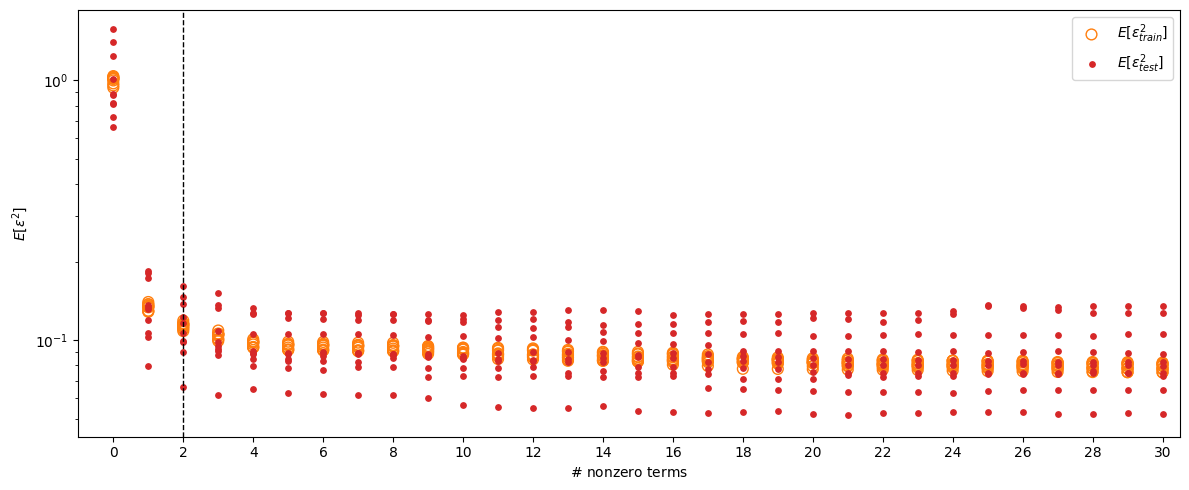

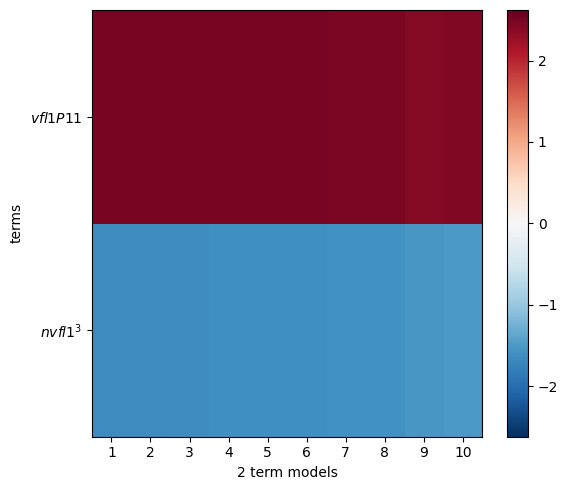

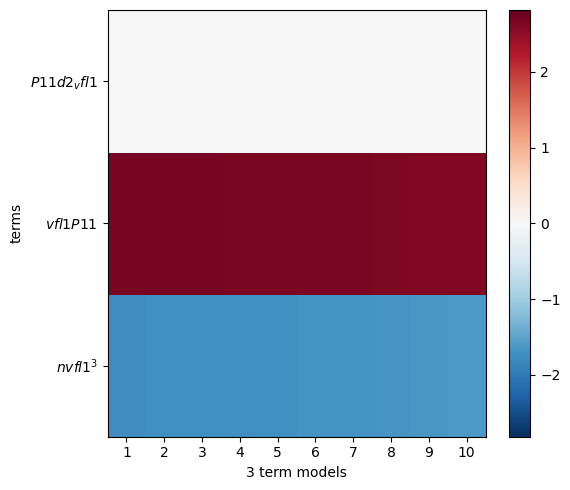

In [25]:
# Alves & Fiuza (PRResearch 4, 033192) analysis: 1-by-1 STLSQ elimination path across
# K folds -> Pareto front (error vs #terms) + stability of the discovered model form.
# Columns restricted to the LASSO support (the O(p^3) elimination path is too slow on
# all 819 terms); rows randomly subsampled (decorrelates neighboring cells; ~1 min).
# Unscaled features + explicit ones column -> coefficients come out physical.
rng_pareto = np.random.default_rng(0)
cols = np.flatnonzero(lasso.coef_)
rows = rng_pareto.choice(X_train.shape[0], size=min(12_000, X_train.shape[0]), replace=False)
poly_names = poly.get_feature_names_out(FEATURES)


def tex_name(name):
    """Mathtext-safe label: brace nested powers, e.g. 'vfl1^3^2' -> '{vfl1^3}^2'."""
    parts = []
    for f in name.split(" "):
        if f.count("^") > 1:
            i = f.rindex("^")
            f = "{" + f[:i] + "}" + f[i:]
        parts.append(f)
    return " ".join(parts)


description = ["1"] + [tex_name(poly_names[j]) for j in cols]

# Ensure X_train/X_test are the polynomial design matrices before indexing with `cols`.
if X_train.shape[1] == len(FEATURES):
    X_train = poly.fit_transform(X_train)
if X_test.shape[1] == len(FEATURES):
    X_test = poly.transform(X_test)

Theta = np.column_stack([np.ones(rows.size), X_train[rows][:, cols]]).astype(np.float64)
Y = y_train[rows].astype(np.float64).reshape(-1, 1)

reg_results = Kfold_STLS_regression__1by1(Theta=Theta, Y=Y, K_folds=10, normalize_Theta=True)

plot_pareto_front_analysis(reg_results, pareto_pos=2)
discovered_Mterm_models(reg_results, description, M=2)
discovered_Mterm_models(reg_results, description, M=3)

# Refit each discovered 2-term sparsity pattern on the full training data, score on test
Theta_full = np.column_stack([np.ones(X_train.shape[0]), X_train[:, cols]]).astype(np.float64)
Theta_test = np.column_stack([np.ones(X_test.shape[0]), X_test[:, cols]]).astype(np.float64)


In [26]:
M = 4
patterns = np.unique(np.abs(reg_results["coeff_evol"][reg_results["num_non_zero_terms"] == M]) > 0, axis=0)
for pattern in patterns:
    idx = np.flatnonzero(pattern)
    xi = LS_estimation_for_given_sparsity_pattern(Theta_full, y_train.astype(np.float64).reshape(-1, 1), description, idx)
    # Theta is built from unscaled features, so xi is already in physical units
    terms = [poly_names[cols[j - 1]] if j > 0 else "" for j in idx]  # Theta column 0 is the intercept
    eq = " + ".join(f"({c:+.4e})" + (f"*{t}" if t else "") for c, t in zip(xi, terms, strict=True))
    print(f"  {TARGET} ~ {eq}")
    print(f"  test R^2 = {r2_score(y_test, Theta_test[:, idx] @ xi):.4f}")

Nonzero terms: ['n vfl1^3' 'vfl1 P11' 'P11 d2_vfl1' 'P11 d4_vfl1']
Mean Coefficient values (on full data): [-1.61636139e+00  2.73008440e+00  1.07530228e-02  3.45740677e-05]
  Q111 ~ (-1.6164e+00)*n vfl1^3 + (+2.7301e+00)*vfl1 P11 + (+1.0753e-02)*P11 d2_vfl1 + (+3.4574e-05)*P11 d4_vfl1
  test R^2 = 0.9096


# 3) Gaussian Process regression

In [27]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel

# GP inputs: the M most important LASSO terms (by |scaled coefficient|), i.e. the same
# ranking used by reconstruct_target. X_train/X_test are the unscaled polynomial design
# matrices, so their columns are the physical values of those terms.
M_GP = 5
nz = np.flatnonzero(lasso.coef_)
lasso_rank = nz[np.argsort(np.abs(lasso.coef_[nz]))[::-1]]  # most important first
top_terms = lasso_rank[:M_GP]
poly_names_all = poly.get_feature_names_out(FEATURES)
print(f"GP inputs (top {M_GP} LASSO terms):", list(poly_names_all[top_terms]))

N_GP_TRAIN = 2000  # exact GP is O(n^3): subset-of-data approximation
rng_gp = np.random.default_rng(3)
sub = rng_gp.choice(X_train.shape[0], size=N_GP_TRAIN, replace=False)

gp_scaler = StandardScaler().fit(X_train[:, top_terms])
Xg_train = gp_scaler.transform(X_train[sub][:, top_terms])
yg_train = y_train[sub].astype(np.float64)
Xg_test = gp_scaler.transform(X_test[:, top_terms])

# One ARD length scale per input; WhiteKernel absorbs PIC deposition noise so the
# smooth kernel does not have to fit it.
kernels = {
    "RBF": ConstantKernel(1.0) * RBF(length_scale=np.ones(M_GP)) + WhiteKernel(1e-2),
    "Matern-3/2": ConstantKernel(1.0) * Matern(length_scale=np.ones(M_GP), nu=1.5) + WhiteKernel(1e-2),
    "Matern-5/2": ConstantKernel(1.0) * Matern(length_scale=np.ones(M_GP), nu=2.5) + WhiteKernel(1e-2),
}

gps = {}
for name, kern in kernels.items():
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, n_restarts_optimizer=1, random_state=0)
    gp.fit(Xg_train, yg_train)
    gps[name] = gp
    print(f"{name:11s}: log marginal likelihood = {gp.log_marginal_likelihood_value_:.1f}   {gp.kernel_}")

# Model selection by evidence: the kernel with the highest marginal likelihood
best_name = max(gps, key=lambda k: gps[k].log_marginal_likelihood_value_)
gp_best = gps[best_name]
print(f"\nSelected kernel (highest evidence): {best_name}")

GP inputs (top 5 LASSO terms): ['vfl1 P11', 'n vfl1^3', 'P11 d2_vfl1', 'n d2_vfl1', 'n d4_vfl1']
RBF        : log marginal likelihood = 46.3   2.42**2 * RBF(length_scale=[0.205, 0.361, 0.274, 4.28, 1.61]) + WhiteKernel(noise_level=0.0152)
Matern-3/2 : log marginal likelihood = 425.6   2.61**2 * Matern(length_scale=[0.428, 1.51, 0.401, 8.25, 1.93], nu=1.5) + WhiteKernel(noise_level=0.00254)
Matern-5/2 : log marginal likelihood = 210.2   2.39**2 * Matern(length_scale=[0.374, 0.813, 0.288, 5.08, 1.36], nu=2.5) + WhiteKernel(noise_level=0.00777)

Selected kernel (highest evidence): Matern-3/2


GP (Matern-3/2)  test R^2 = 0.3497   (LASSO: 0.9195)
Calibration on test sim: 76.3% inside 1 sigma (ideal 68.3%), 91.7% inside 1.96 sigma (ideal 95.0%)


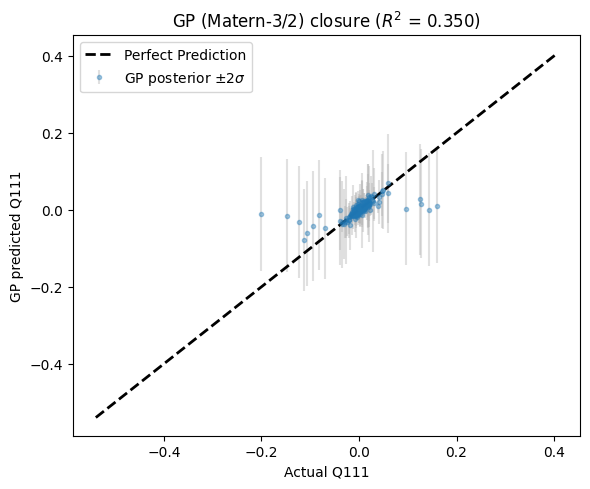

In [28]:
def gp_predict_chunked(gp, X, chunk=8192):
    """Predict mean and std in chunks (the full test kernel matrix would be ~0.5 GB)."""
    means, stds = [], []
    for i in range(0, X.shape[0], chunk):
        m, s = gp.predict(X[i : i + chunk], return_std=True)
        means.append(m)
        stds.append(s)
    return np.concatenate(means), np.concatenate(stds)


y_gp_mean, y_gp_std = gp_predict_chunked(gp_best, Xg_test)
r2_gp = r2_score(y_test, y_gp_mean)

# Calibration: if sigma(x) is honest, |z| < 1 for ~68.3% of points and < 1.96 for ~95%
z = (y_test - y_gp_mean) / y_gp_std
cov68 = np.mean(np.abs(z) < 1.0)
cov95 = np.mean(np.abs(z) < 1.96)
print(f"GP ({best_name})  test R^2 = {r2_gp:.4f}   (LASSO: {r2_test:.4f})")
print(f"Calibration on test sim: {100 * cov68:.1f}% inside 1 sigma (ideal 68.3%), {100 * cov95:.1f}% inside 1.96 sigma (ideal 95.0%)")

# Scatter with 2-sigma error bars on a random subset (all ~33k points would be unreadable)
show = rng_gp.choice(y_test.size, size=400, replace=False)
plt.figure(figsize=(6, 5))
plt.errorbar(
    y_test[show],
    y_gp_mean[show],
    yerr=2 * y_gp_std[show],
    fmt="o",
    ms=3,
    alpha=0.4,
    ecolor="0.7",
    label=r"GP posterior $\pm 2\sigma$",
)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2, label="Perfect Prediction")
plt.xlabel("Actual Q111")
plt.ylabel("GP predicted Q111")
plt.title(f"GP ({best_name}) closure ($R^2$ = {r2_gp:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "gp_scatter_test.png", dpi=200)
plt.show()

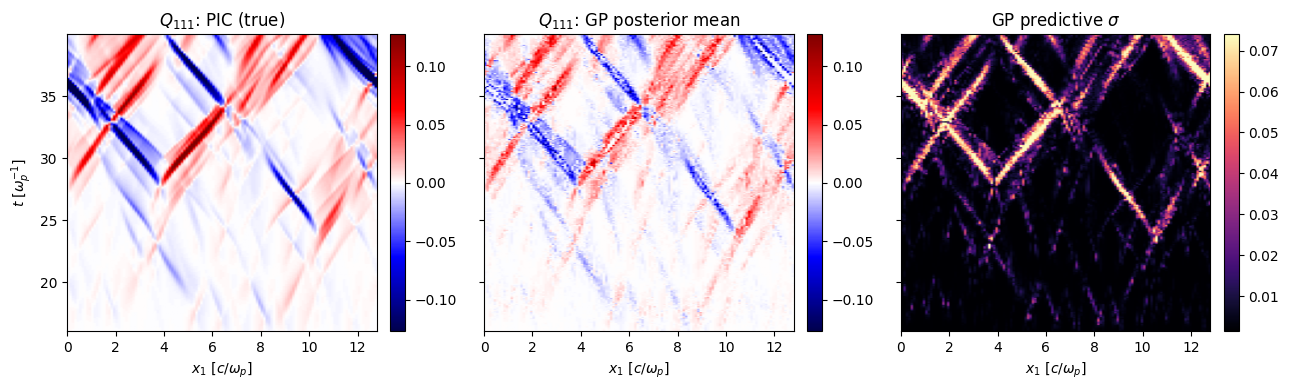

In [29]:
sim_idx = 0  # choose which test sim to visualize (0..len(test_labels)-1)
sim = test_labels[sim_idx]

# compute segment offsets for the chosen sim
lengths = [arr.size for arr in y_test_sims]
offset = sum(lengths[:sim_idx])
L = lengths[sim_idx]

y_true_seg = y_test[offset : offset + L]
y_pred_seg = y_gp_mean[offset : offset + L]
y_std_seg = y_gp_std[offset : offset + L]
t_seg = t_test_sims[sim_idx]

# reshape into (n_t, n_x1)
n_t = len(np.unique(t_seg))
if y_true_seg.size % n_t != 0:
    raise ValueError(f"Cannot reshape segment of size {y_true_seg.size} into (n_t={n_t}, -1).")

n_x1 = y_true_seg.size // n_t
true_map = y_true_seg.reshape(n_t, n_x1)
pred_map = y_pred_seg.reshape(n_t, n_x1)
std_map = y_std_seg.reshape(n_t, n_x1)

ext = [0, n_x1 * DX, float(t_seg[0]), float(t_seg[-1])]
fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
vmax = np.percentile(np.abs(true_map), 99)
for a, arr, title, kw in (
    (ax[0], true_map, "PIC (true)", dict(cmap="seismic", vmin=-vmax, vmax=vmax)),
    (ax[1], pred_map, "GP posterior mean", dict(cmap="seismic", vmin=-vmax, vmax=vmax)),
    (ax[2], std_map, r"GP predictive $\sigma$", dict(cmap="magma")),
):
    im = a.imshow(arr, origin="lower", aspect="auto", extent=ext, **kw)
    a.set_xlabel(r"$x_1\ [c/\omega_p]$")
    a.set_title(rf"$Q_{{111}}$: {title}" if "sigma" not in title else title)
    plt.colorbar(im, ax=a, fraction=0.046, pad=0.04)
ax[0].set_ylabel(r"$t\ [\omega_p^{-1}]$")
fig.tight_layout()
fig.savefig(FIG_DIR / f"gp_map_{sim}.png", dpi=200)
plt.show()

M= 1: GP R^2 = 0.7522   truncated-linear R^2 = 0.7507
M= 2: GP R^2 = 0.1994   truncated-linear R^2 = 0.8909
M= 3: GP R^2 = 0.2232   truncated-linear R^2 = 0.8920
M= 5: GP R^2 = 0.3497   truncated-linear R^2 = 0.8891
M=10: GP R^2 = 0.4043   truncated-linear R^2 = 0.9016


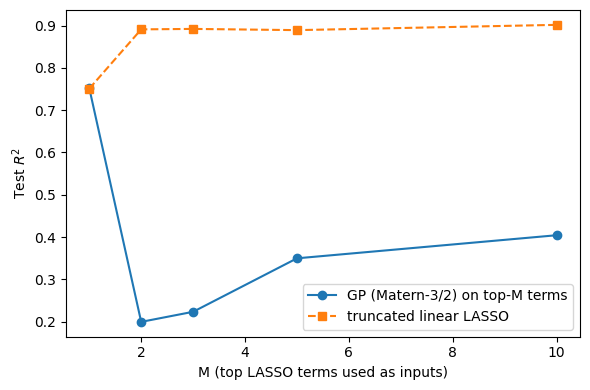

In [30]:
# GP vs truncated-linear closure on the same top-M LASSO coordinates
M_VALUES = (1, 2, 3, 5, 10)
kern_factory = {
    "RBF": lambda M: RBF(length_scale=np.ones(M)),
    "Matern-3/2": lambda M: Matern(length_scale=np.ones(M), nu=1.5),
    "Matern-5/2": lambda M: Matern(length_scale=np.ones(M), nu=2.5),
}[best_name]

r2_gp_M, r2_lin_M = [], []
for M in M_VALUES:
    cols_M = lasso_rank[:M]
    scaler_M = StandardScaler().fit(X_train[:, cols_M])
    gp_M = GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * kern_factory(M) + WhiteKernel(1e-2),
        normalize_y=True,
        n_restarts_optimizer=1,
        random_state=0,
    ).fit(scaler_M.transform(X_train[sub][:, cols_M]), yg_train)
    mean_M, _ = gp_predict_chunked(gp_M, scaler_M.transform(X_test[:, cols_M]))
    r2_gp_M.append(r2_score(y_test, mean_M))

    # truncated linear LASSO closure on the same terms (all other coefficients zeroed)
    y_lin = X_test_scaled[:, cols_M] @ lasso.coef_[cols_M] + lasso.intercept_
    r2_lin_M.append(r2_score(y_test, y_lin))
    print(f"M={M:2d}: GP R^2 = {r2_gp_M[-1]:.4f}   truncated-linear R^2 = {r2_lin_M[-1]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(M_VALUES, r2_gp_M, "o-", label=f"GP ({best_name}) on top-M terms")
plt.plot(M_VALUES, r2_lin_M, "s--", label="truncated linear LASSO")
plt.xlabel("M (top LASSO terms used as inputs)")
plt.ylabel(r"Test $R^2$")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "gp_vs_M.png", dpi=200)
plt.show()